# Home Credit experiment inspection and reproduction

This technical notebook documents the data interfaces, fixed modelling rules, saved-prediction checks and local experimental observations. Run it sequentially in a clean kernel. Default execution audits existing results and performs no training. Formal authorship, AI disclosure and the overall scientific conclusion are in the accompanying midterm Mini-Project 1 report (final version, 9 October 2026).

### Execution contract and cache identity
**Problem.** Reuse must not silently mix predictions, split versions or changed code. **Inputs.** Local helper, `support/manifest.json` (file hashes) and frozen protocol JSON. **Output.** Counts of verified files and unchanged training source modules. A mismatch raises an assertion; repair the source discrepancy before continuing, rather than relabelling a cache as valid.

Run cells sequentially in a fresh Python kernel from the extracted package directory. The default path uses NumPy, pandas and scikit-learn; LightGBM is needed only for deliberate training. This is a saved-prediction audit, not fresh training or model replay. The historical A bundles were replayed in the earlier experiment; original B/C outer bundles were not persisted. The technical provenance distinguishes those evidence levels.

In [1]:
from pathlib import Path
import sys, json, inspect
import pandas as pd
from IPython.display import display, Image, Markdown
candidates = [q for p in [Path.cwd(), *Path.cwd().parents] for q in (p, p/'notebooks')]
BASE = next(p for p in candidates if (p/'workflow.py').exists() and (p/'support/manifest.json').exists())
sys.path.insert(0, str(BASE))
import workflow as w
pd.set_option('display.precision', 6)
print('Verified packaged files:', w.verify_manifest())
print('Unchanged frozen training sources:', w.verify_frozen_source())
print('This execution performs prediction/metric verification, not model training.')

Verified packaged files: 63
Unchanged frozen training sources: 5
This execution performs prediction/metric verification, not model training.


## 1. Data and a common observational unit
One row is one labelled application, identified by `SK_ID_CURR`; `TARGET=1` denotes payment difficulty. ID is used for joins/split/prediction alignment and is never a predictor. The labelled cohort has 307,511 applications and 24,825 positives (about 8.07%). Official test labels are unavailable locally.

Historical records are aggregated at applicant level and left-joined, retaining applicants with no history. Seventeen bureau records with `DAYS_CREDIT_UPDATE > 0` were excluded before aggregation in the authorised data audit. Record counts are not necessarily numbers of unique loans. `INSTALL_AVG_DAYS_LATE` was an old name for mean actual-payment-day offset, not delay relative to scheduled payment.

The descriptive statistics below originate from the saved, audited data/EDA module. Default execution rechecks their file integrity, not reconstruction of all raw tables. Prior raw-data checks and A-model replay are separately recorded; B/C outer-fold models were not persisted.

### Inspect the cohort and descriptive inputs
**Inputs.** `membership.csv` has one row per applicant with ID, binary TARGET, partition and fold; saved EDA CSVs describe columns. **Outputs.** Split counts, class fractions, audit information and the shared EDA figure. ID and TARGET checks fail before metrics if the cohort changes.

The 8.07% positive fraction motivates AP alongside ROC AUC. Missing historical records are retained; missingness describes unavailable information and does not justify deleting applicants or filling excluded historical variables with fabricated zeros. Descriptive EDA uses all labelled applicants; learned imputation/encoding/scaling does not. The missingness panel counts the 67 application fields with nonzero missingness in the saved audit, using 10-percentage-point bins. Zero-missingness fields and joined-history features are not included; this is not a distribution over all A/B/C inputs.

applicants  positives  positive_rate
partition   fold                                      
development  0         97379       7862       0.080736
             1         97378       7861       0.080727
             2         97378       7861       0.080727
holdout     -1         15376       1241       0.080710

,status,train_shape,test_shape,class_counts,numeric_inputs,categorical_inputs,missing_columns,high_missing_columns,constant_columns,reconstruction_mismatches,historical_future_records_in_used_offsets,bureau_excluded_records,bureau_changed_cells,seconds
0,passed_with_authorized_bureau_filter,"[307511, 153]","[48744, 152]","{'0': 282686, '1': 24825}",135,16,90,51,[],0,0,17,82,11.591233


,Unnamed: 0,missing_count,missing_ratio
0,COMMONAREA_MEDI,214865,0.698723
1,COMMONAREA_AVG,214865,0.698723
2,COMMONAREA_MODE,214865,0.698723
3,NONLIVINGAPARTMENTS_MODE,213514,0.694330
4,NONLIVINGAPARTMENTS_AVG,213514,0.694330
5,NONLIVINGAPARTMENTS_MEDI,213514,0.694330
6,FONDKAPREMONT_MODE,210295,0.683862
7,LIVINGAPARTMENTS_MODE,210199,0.683550
8,LIVINGAPARTMENTS_AVG,210199,0.683550
9,LIVINGAPARTMENTS_MEDI,210199,0.683550


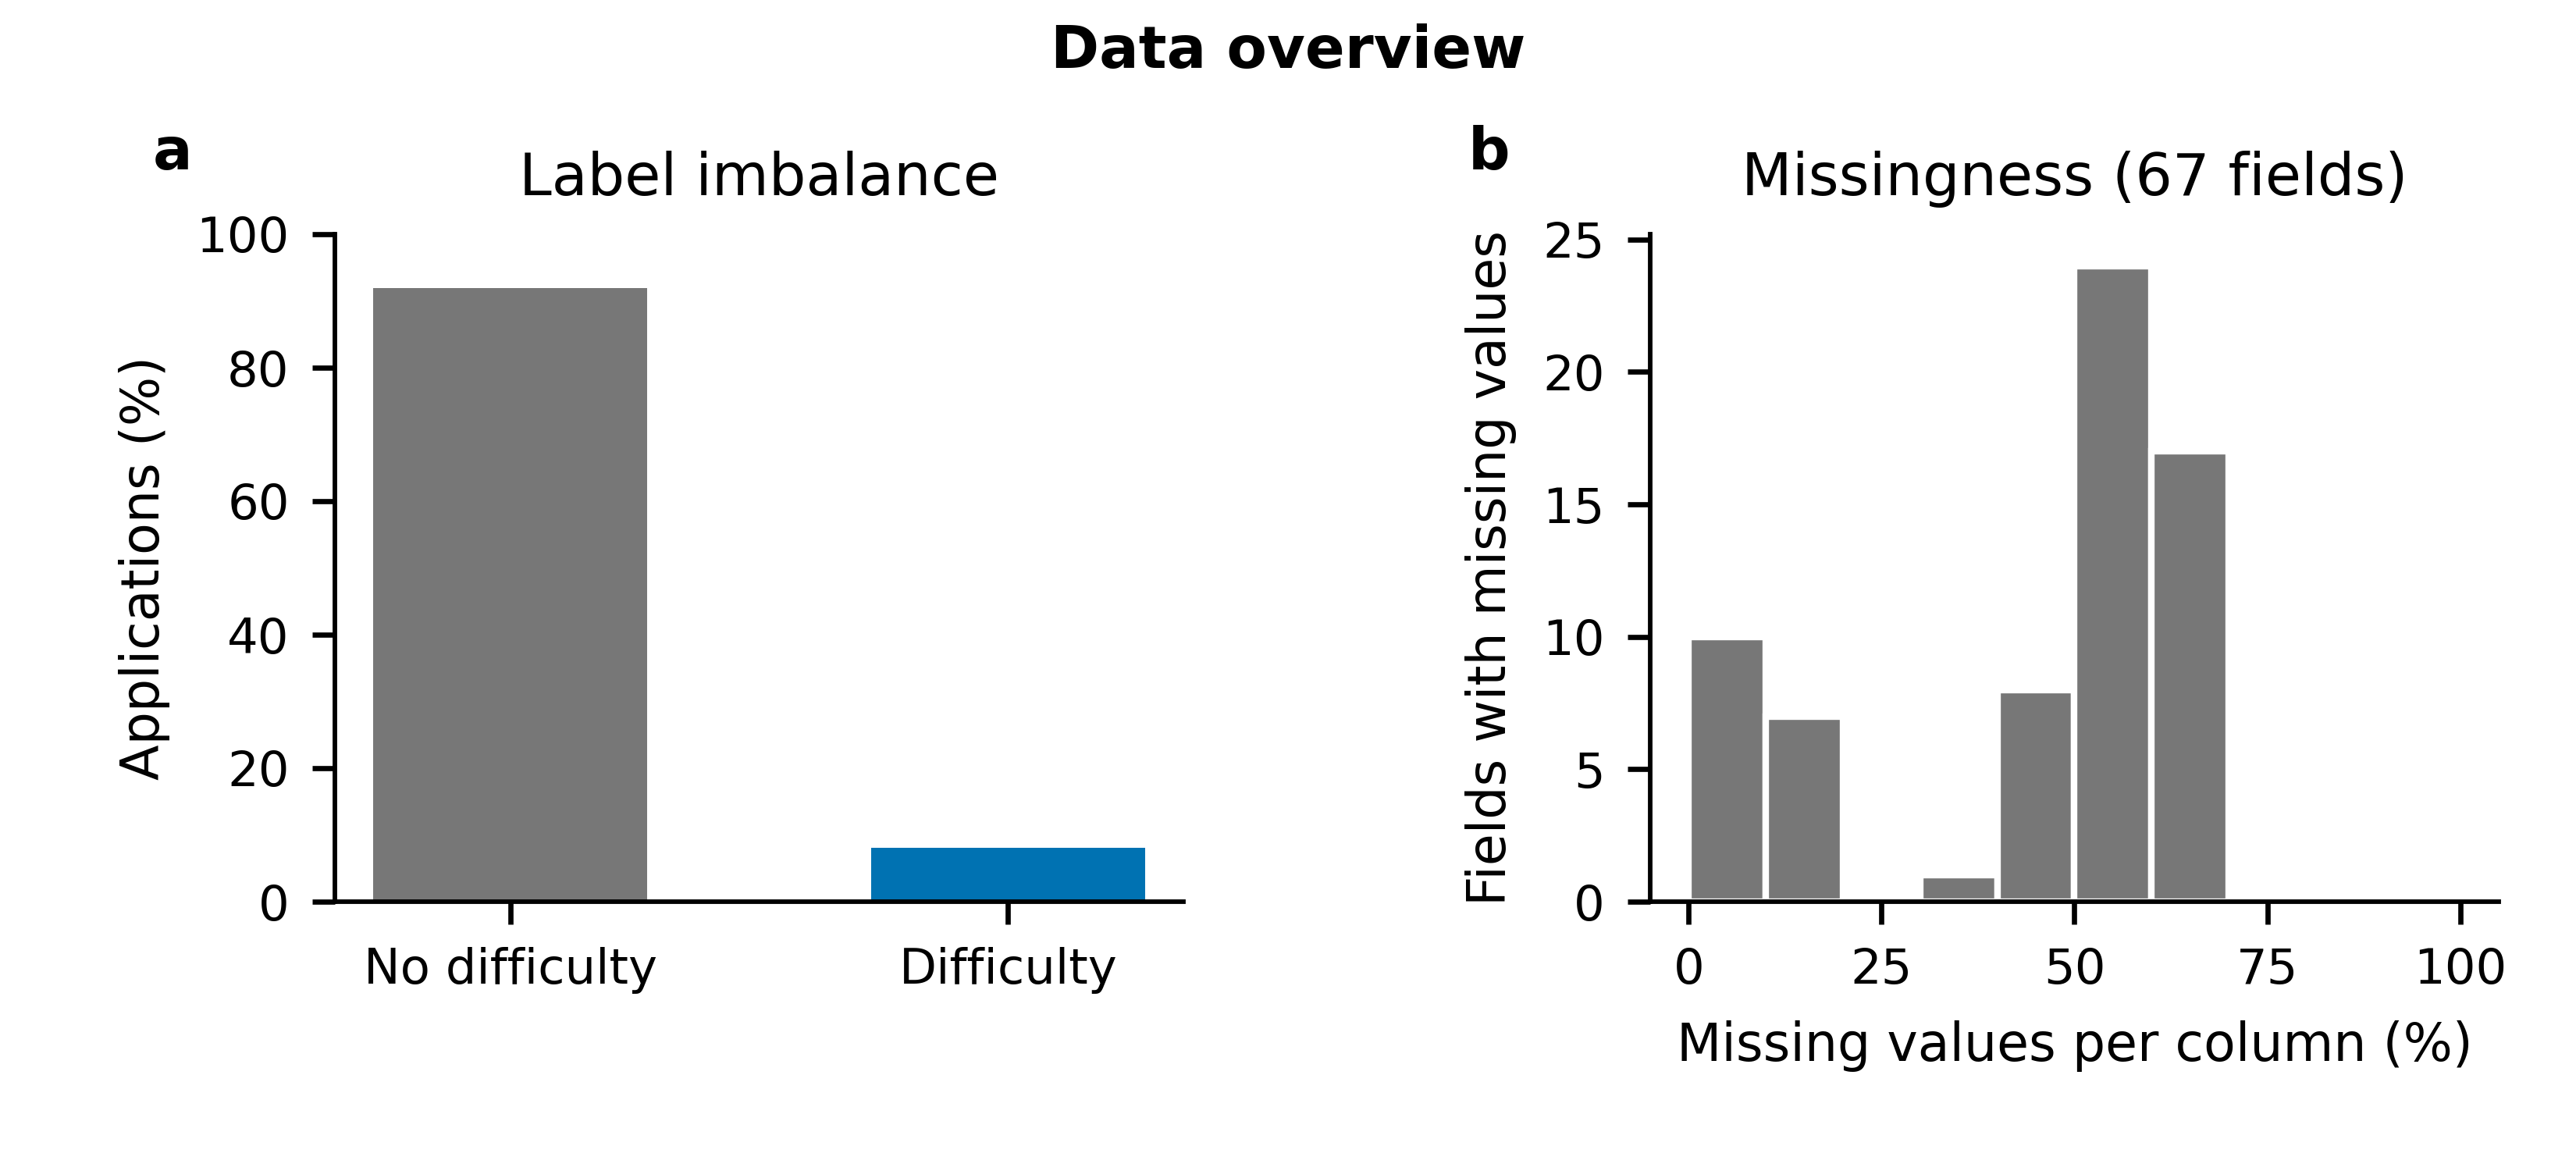

In [2]:
membership = w.read_csv('support/membership.csv')
data_audit = json.loads((BASE/'support/data/data_audit.json').read_text())
assert len(membership)==307511 and membership.SK_ID_CURR.is_unique
assert int(membership.TARGET.sum())==24825
split_summary = membership.groupby(['partition','fold']).agg(applicants=('SK_ID_CURR','size'),positives=('TARGET','sum'))
split_summary['positive_rate'] = split_summary.positives/split_summary.applicants
display(split_summary)
display(pd.DataFrame([data_audit]).drop(columns=['comparison_tolerance']))
display(w.read_csv('support/data/missing_statistics.csv').head(10))
display(Image(filename=str(BASE.parent/'figures/eda.png'),width=800))

## 2. Separate information expansion from pipeline changes
- **A, application table only.** All original application fields, plus shared income/credit and annuity/income ratios, age and employment duration in years. External scores and credit-inquiry counts already present in the application table remain included. A excludes all joined history features and their dependent ratios/missingness indicators.
- **B, basic history (original V1).** A plus 27 historical aggregates.
- **C, enhanced history (original V2).** B plus 39 behavioural-history features derived from repayments, recent/structural histories and bureau monthly records.

A/B/C have 126/153/192 table columns including ID and label. These are not final model dimensions. Each pipeline has its own encoding and application-based transformations. Missing employment sentinel `365243` is handled before learned imputation; it is not interpreted as unemployment. No applicants are discarded because history is absent.

### Trace information sources through model-specific representations
**Input.** `feature_sets.json` maps A/B/C shared columns to source and each model's pre-encoding names and per-fold output names. **Output.** Shared-table, model-input and encoded widths. They are different quantities: ID/label occur only in the shared table; categorical expansion depends on training-fold categories.

A is constructed from the raw application schema plus four deterministic within-application derivatives. Original application external scores and bureau-inquiry counts remain. The RF A branch applies the same pruning and safe division primitives, but includes a ratio only when both operands are present; history-dependent flags are absent. No B/C fitted preprocessor is reused for A. Full lineage is available for auditing individual names, beyond the compact count table.

The repayment late-rate denominator comprises valid loan-period events due by application time. `repayment_features` in `source_snapshot/baseline/baseline_features_v2.py` retains the highest observed schedule version per applicant, loan and instalment. It excludes whole events with missing payment dates/amounts, invalid scheduled amounts or conflicting schedules. Missing payment information is not automatically classified as late. Eligible split payments are summed; future payments do not count as paid at application time. Excluding an event does not remove its applicant. The recent rate uses eligible due dates in the preceding 365 days.


In [3]:
display(w.feature_counts())
feature_sets = json.loads((BASE/'support/abc/feature_sets.json').read_text())
print('Complete field lineage and per-fold names: support/abc/feature_sets.json')

,group,table_columns,model,input_columns,encoded_widths
0,A,126,LR,123,"407, 408"
1,A,126,RF,97,"226, 227"
2,A,126,LGB,123,123
3,B,153,LR,150,"461, 462"
4,B,153,RF,153,"282, 283"
5,B,153,LGB,150,150
6,C,192,LR,189,"539, 540"
7,C,192,RF,231,"360, 361"
8,C,192,LGB,189,189


Complete field lineage and per-fold names: support/abc/feature_sets.json


## 3. Fixed experimental design
The original ID-based split assigns 95% to development (292,135 applicants) and 5% to a previously viewed holdout (15,376). Three development folds are fixed with seed 5054. All nine pipeline/information combinations use the same ID, label and fold assignments.

**AUC** measures ranking discrimination across positive/negative examples. **AP** summarises precision across recall levels and provides a complementary view under class imbalance. **OOF scores** are predictions on a fold excluded from the model's training. Our primary result is the **unweighted mean of three fold AUCs**, not AUC computed after pooling all OOF scores. Error bars are **sample SD (ddof=1), not confidence intervals**. Validation metrics use the natural label distribution, without class weights.

A was added retrospectively after B/C had been observed. We report paired descriptive differences, not statistical significance, independent generalisation or a causal effect of algorithm complexity. Holdout and Kaggle scores are displayed only as supplementary evidence and are not used for model selection.

### Fix modelling choices before comparing information sets
**Input.** The original protocol stores LR/RF/LightGBM configurations and the inner early-stopping rule. **Output.** Exact fixed configuration dictionaries. A/B/C vary information sources while preserving these model-specific rules; later C11 settings cannot enter this block.

Membership uses seed 5054; RF/model seeds and the LightGBM inner partition use 42. For each outer fold, preprocessing is fitted only on its complementary development rows. LightGBM selects rounds using a stratified 10% subset of those training rows, max 1,000 rounds/patience 50 and unweighted AUC. It then fits a fresh category processor and booster on all outer-training rows. The outer validation labels never select the stopping round. Information-value (IV) screening was disabled in the formal unified protocol (`iv=False`); this experiment did not perform fold-local IV selection.

In [4]:
protocol=json.loads((BASE/'support/original_protocol.json').read_text())['protocol']
for name in ['lr','rf','lgb','early_stopping']:
    print(name.upper());display(pd.Series(protocol[name],name='Fixed setting'))

LR


penalty         elasticnet
C                     0.01
l1_ratio              0.25
class_weight      balanced
Name: Fixed setting, dtype: object

RF


n_estimators                     300
max_depth                         15
min_samples_leaf                  50
max_features                     0.1
class_weight        {'0': 1, '1': 2}
criterion                       gini
bootstrap                       True
random_state                      42
n_jobs                             4
Name: Fixed setting, dtype: object

LGB


objective            binary
metric                  auc
learning_rate           0.1
max_depth                 2
num_leaves               31
min_data_in_leaf         20
min_gain_to_split      0.01
seed                     42
num_threads               4
verbosity                -1
zero_as_missing       False
use_missing            True
deterministic          True
force_col_wise         True
feature_fraction        1.0
bagging_fraction        1.0
bagging_freq              0
lambda_l1               0.0
lambda_l2               0.0
max_bin                 255
Name: Fixed setting, dtype: object

EARLY_STOPPING


inner_fraction                      0.1
seed                                 42
max_rounds                         1000
patience                             50
metric                   unweighted AUC
outer_validation_used             False
Name: Fixed setting, dtype: object

### Report Figure 1: inspect the evaluation boundary
Deterministic aggregation is separate from fitted preprocessing. The arrows into each validation score use the processor learned only on its training portion. The viewed holdout is outside this CV route.

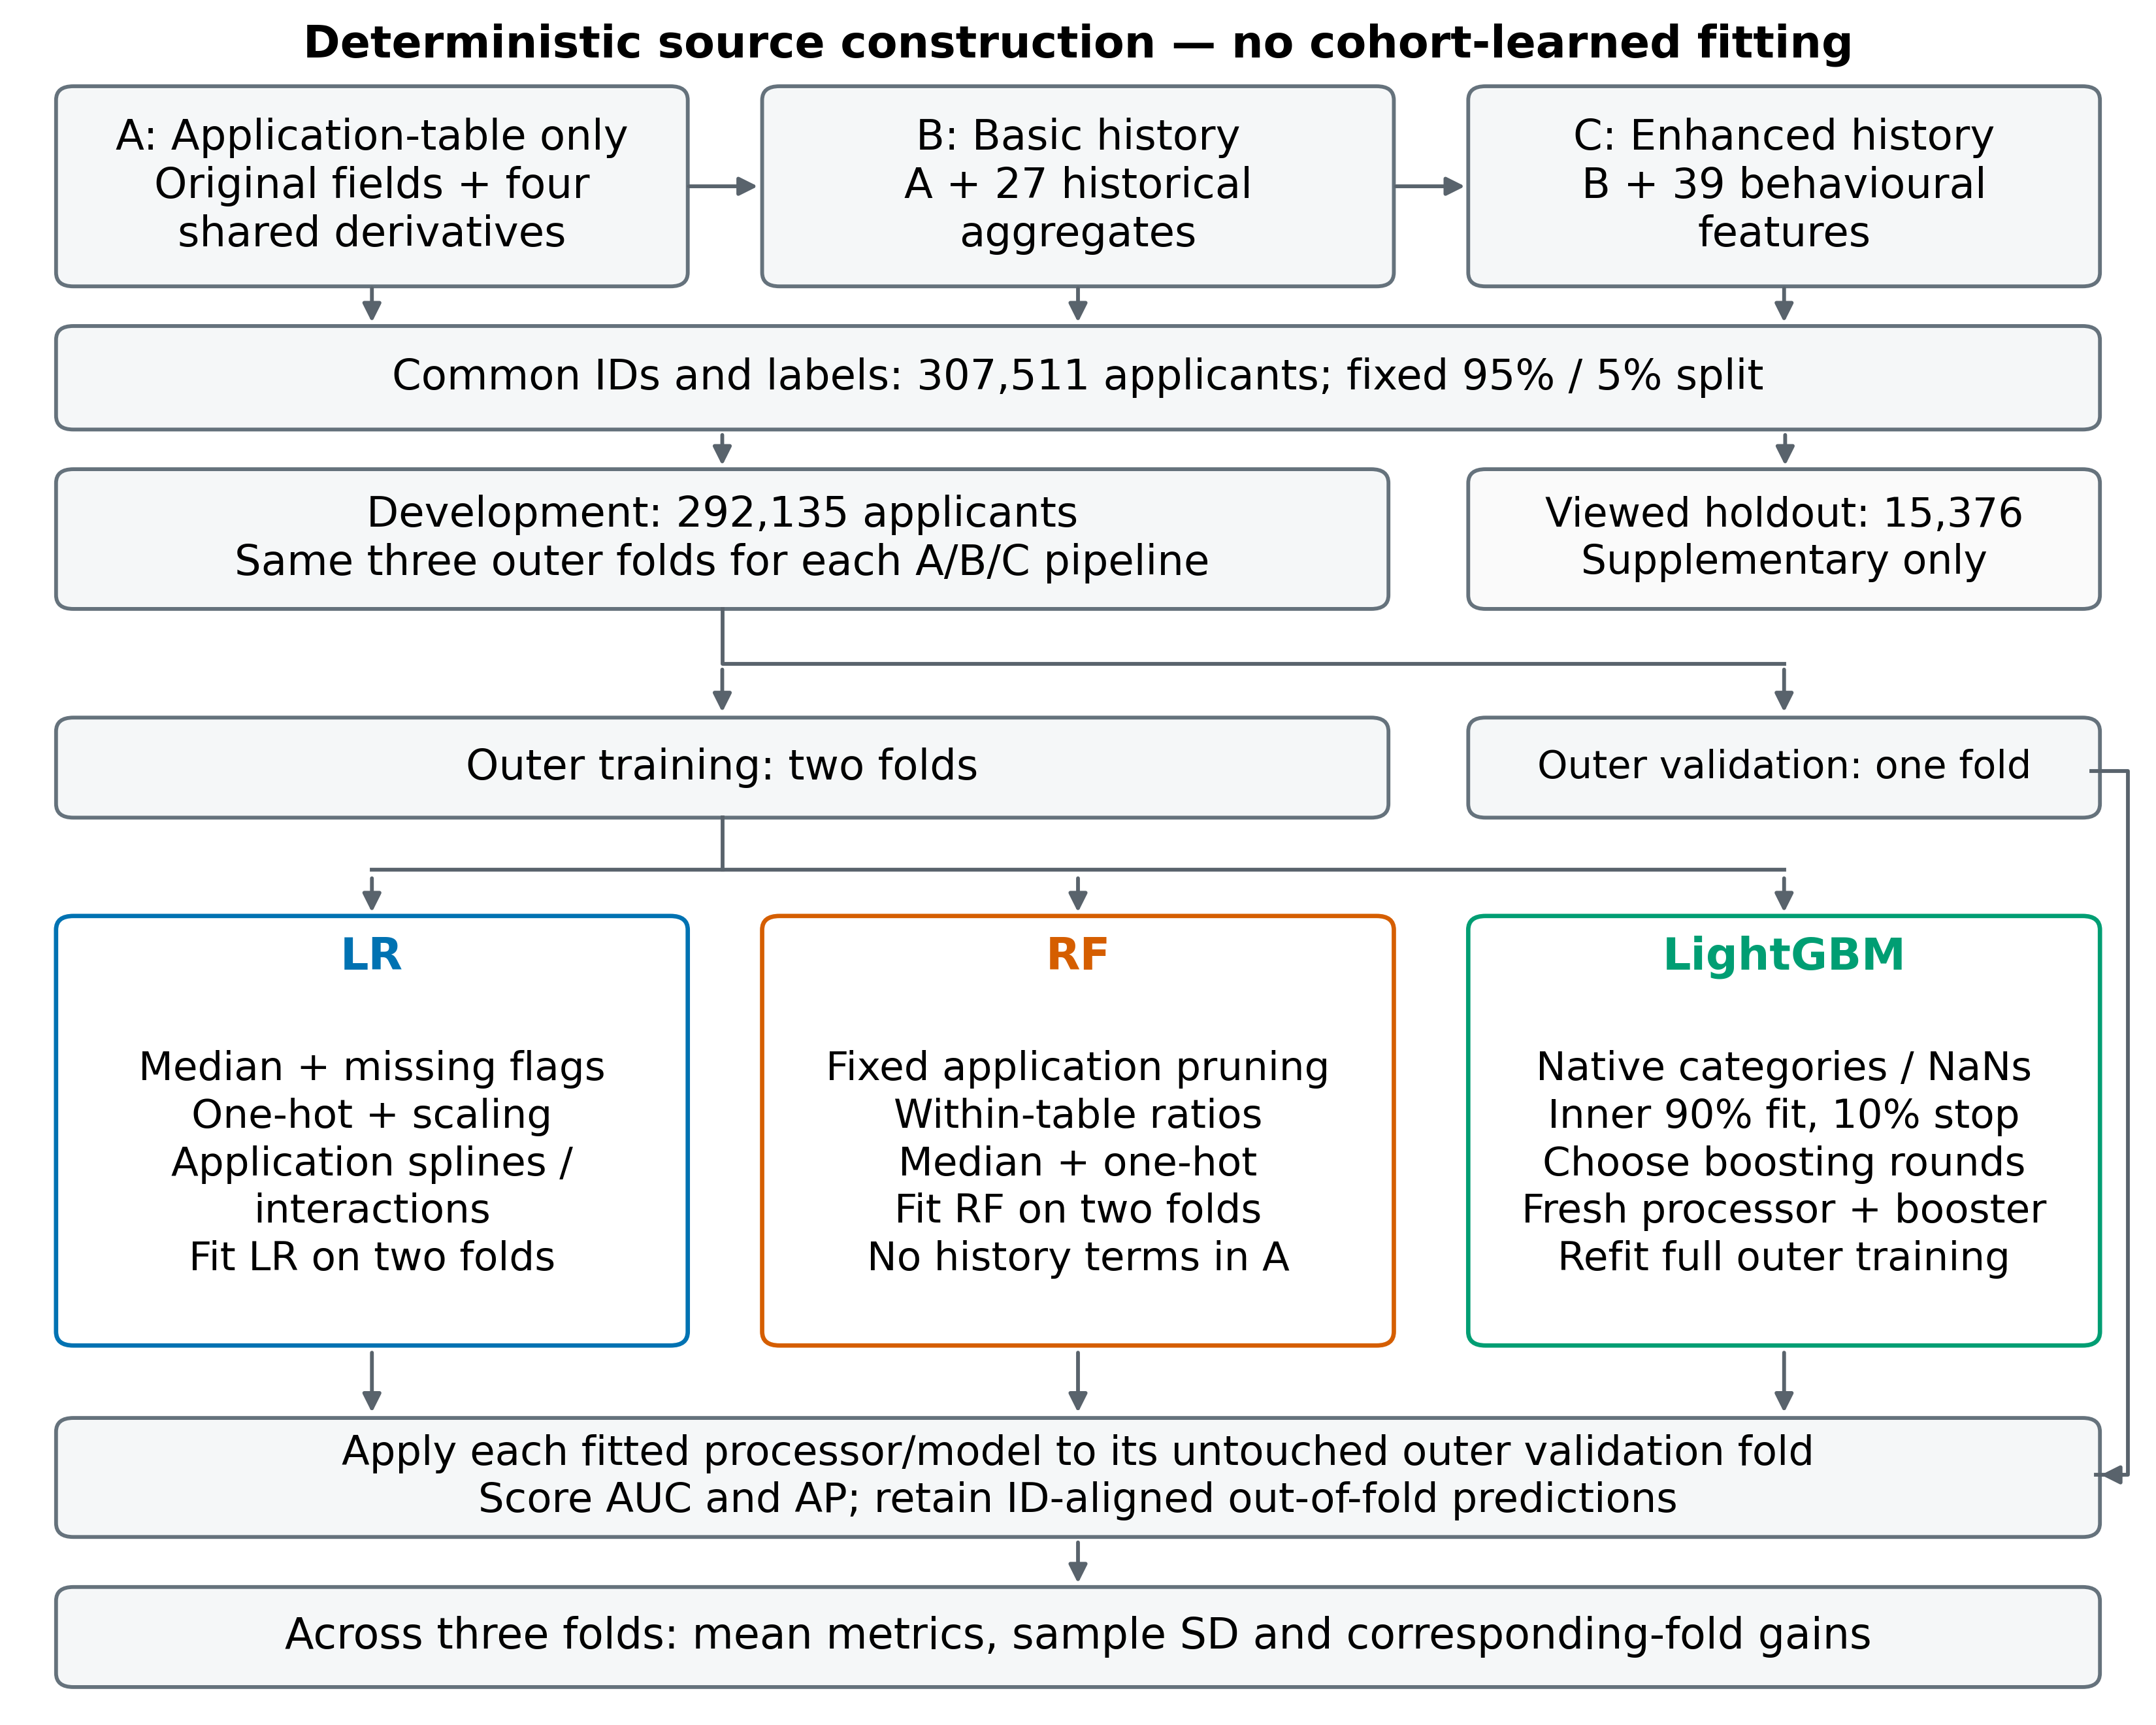

In [5]:
display(Image(filename=str(BASE.parent/'figures/study_design.png'),width=800))

## 4. Three complete modelling pipelines
**LR (baseline).** Training-fold median imputation, numeric missing indicators, six predefined log transforms, full one-hot coding, nonbinary scaling and application-only spline/interaction terms. The fixed elastic-net model uses C=0.01, L1 ratio 0.25 and balanced class weights. The original numerical solver minimises the equivalent penalised objective and checks the KKT residual.

**RF (bagging).** Retain the member's application-field pruning, median imputation, one-hot coding and within-application ratios. A omits six history-dependent business ratios and historical missing/no-record flags. Fixed 300 trees, depth 15, minimum leaf 50, feature fraction 0.1 and class weights 1:2. Increasing columns also changes the absolute feature count sampled per split; this is an information-set comparison within a fixed pipeline, not a claim that only one isolated factor inside the algorithm changes.

**LGB (boosting).** Native categorical values and NaNs, depth 2 and learning rate 0.1. Each outer training set has its own stratified 10% early-stopping partition (maximum 1,000 rounds, patience 50), followed by fresh preprocessing and refitting on the entire outer training set. The outer validation fold is not used for early stopping. Later C11 optimisation is excluded from this A/B/C block.

Implementation is included in `source_snapshot/`. These source files are byte-identical to the actual training implementations; the next cell exposes the common training dispatch used in the runs.

### Inspect the actual fit implementation
The following code is extracted with Python AST from the original source, not reimplemented for presentation. The dispatcher consumes an outer-training feature frame, labels, IDs and a model/version tag and returns a bundle with model, fitted preprocessor and timing/round information. `predict` transforms validation rows with that fitted processor. LR adds application-based spline/interaction terms and minimises the fixed Elastic-Net objective; RF learns a training-only median/one-hot pipeline; LightGBM separately selects rounds and refits. Source snapshots include the component definitions and solver checks, so inspection can continue beyond this dispatch.

In [6]:
import ast
source_path=BASE/'source_snapshot/unified/run.py'
source=source_path.read_text()
node=next(n for n in ast.parse(source).body if isinstance(n,ast.FunctionDef) and n.name=='fit')
display(Markdown('```python'+chr(10)+ast.get_source_segment(source,node)+chr(10)+'```'))

```python
def fit(name,version,x,y,ids,tag,rounds=None):
    started=time.perf_counter();info={}
    if name=='LR':
        prep=ExtensionPreprocessor(['N'] if version=='v1' else ['B','H','N','R'])
        z=prep.fit_transform(x);model,info=fit_model(z,np.asarray(y),LR_CONFIG)
    elif name=='RF':
        prep,_,_=build_feature_preprocessor(x);z=prep.fit_transform(x)
        model=RandomForestClassifier(**RF_CONFIG).fit(z,y)
    else:
        if rounds is None:rounds=select_lgb_rounds(x,np.asarray(y),ids,tag)
        prep,model=fit_lgb_fixed(x,y,rounds);info['rounds']=int(rounds)
    info.update(seconds=time.perf_counter()-started,training_rows=len(x),tag=tag,
                fitting_origin='new_training',fit_count=2 if name=='LGB' and 'fold' in tag else 1)
    return dict(preprocessor=prep,model=model,model_name=name,version=version,info=info)
```

## 5. Primary evidence: fixed A/B/C comparisons
A consists of nine newly fitted outer models plus three internal LGB early-stop fits from the completed A experiment. B/C consist of 18 authenticated historical folds under the same frozen original protocol. Their original outer-fold models were not persisted, so B/C reuse is a verified-prediction reuse, not a new training or model-replay claim.

The following calculation reads every OOF score with round-trip floating-point parsing, verifies application/label/fold alignment and recomputes all 27 fold AUC/AP values, all nine summaries and all paired differences. Prior A-model full-fold replay and raw-input/source checks were performed in the original project. Their internal audit logs are not included in this repository, and those checks are not counted as rerun by this notebook.

### Recompute fold metrics from saved out-of-fold scores
**Input.** The losslessly compressed long-form OOF table has `model`, `group`, `SK_ID_CURR`, `TARGET`, `fold` and `probability`; there are 2,629,215 rows = 9 combinations × 292,135 development applicants. **Output.** 27 fold metric rows, nine mean/SD rows and verified paired deltas.

The helper aligns by applicant key, rejects duplicate/missing IDs, checks labels/folds and finite [0,1] scores, then recalculates ROC AUC and AP separately within each fold. CSV parsing uses `float_precision="round_trip"` to preserve floating-point order/ties. Summary SD uses ddof=1. Tolerance 1e-14 compares reconstructed metrics with the saved record. Pooled OOF AUC is not substituted for mean fold AUC.

In [7]:
cv, summary, deltas, verification = w.verify_abc()
display(cv)
display(summary)
display(pd.Series(verification))

,model,group,fold,roc_auc,ap
0,LGB,A,0,0.760025,0.242287
1,LGB,A,1,0.757408,0.246959
2,LGB,A,2,0.754173,0.236799
3,LGB,B,0,0.775032,0.264857
4,LGB,B,1,0.771800,0.262757
5,LGB,B,2,0.769443,0.257919
6,LGB,C,0,0.783100,0.272543
7,LGB,C,1,0.779081,0.274075
8,LGB,C,2,0.778509,0.269964
9,LR,A,0,0.754786,0.236729


,model,group,auc_mean,auc_sd,ap_mean,ap_sd
0,LGB,A,0.757202,0.002931,0.242015,0.005085
1,LGB,B,0.772092,0.002806,0.261844,0.003558
2,LGB,C,0.780230,0.002502,0.272194,0.002077
3,LR,A,0.752941,0.002480,0.235495,0.005742
4,LR,B,0.762607,0.002519,0.247233,0.004490
5,LR,C,0.773946,0.002712,0.259914,0.003725
6,RF,A,0.751752,0.001586,0.234018,0.004988
7,RF,B,0.762813,0.001045,0.247623,0.005439
8,RF,C,0.766000,0.001153,0.253352,0.004365


status                                                         PASS
oof_rows                                                    2629215
fold_scores                                                      27
new_model_fits                                                    0
scope             OOF/ID/label/fold and arithmetic verification;...
dtype: object

### Preserve the matched comparison
**Input.** The fold metric table and saved paired differences. **Output.** Means and every fold difference for B−A, C−B and C−A, followed by shared report figures. A contrast subtracts the same model's scores on the same applicant fold, not scores across unrelated fits.

The level plot shows three-fold mean ± sample SD; its AUC axis is explicitly zoomed. The paired figure displays all 27 fold contrasts with circle/square/triangle for folds 0/1/2 and a short line for each mean. These folds share training data, so SD is not a confidence interval and no significance annotation is added. All recorded differences are retained irrespective of sign.

,model,contrast,fold,auc_delta,ap_delta
3,LR,B-A,mean,0.009667,0.011738
7,LR,C-B,mean,0.011339,0.012681
11,LR,C-A,mean,0.021006,0.024419
15,RF,B-A,mean,0.011061,0.013605
19,RF,C-B,mean,0.003187,0.005728
23,RF,C-A,mean,0.014248,0.019334
27,LGB,B-A,mean,0.014890,0.019829
31,LGB,C-B,mean,0.008138,0.010350
35,LGB,C-A,mean,0.023029,0.030179


,model,contrast,fold,auc_delta,ap_delta
0,LR,B-A,0,0.010251,0.013444
1,LR,B-A,1,0.008864,0.008942
2,LR,B-A,2,0.009885,0.012829
4,LR,C-B,0,0.011937,0.012955
5,LR,C-B,1,0.010347,0.011322
6,LR,C-B,2,0.011733,0.013765
8,LR,C-A,0,0.022188,0.026399
9,LR,C-A,1,0.019211,0.020264
10,LR,C-A,2,0.021618,0.026595
12,RF,B-A,0,0.010658,0.011870


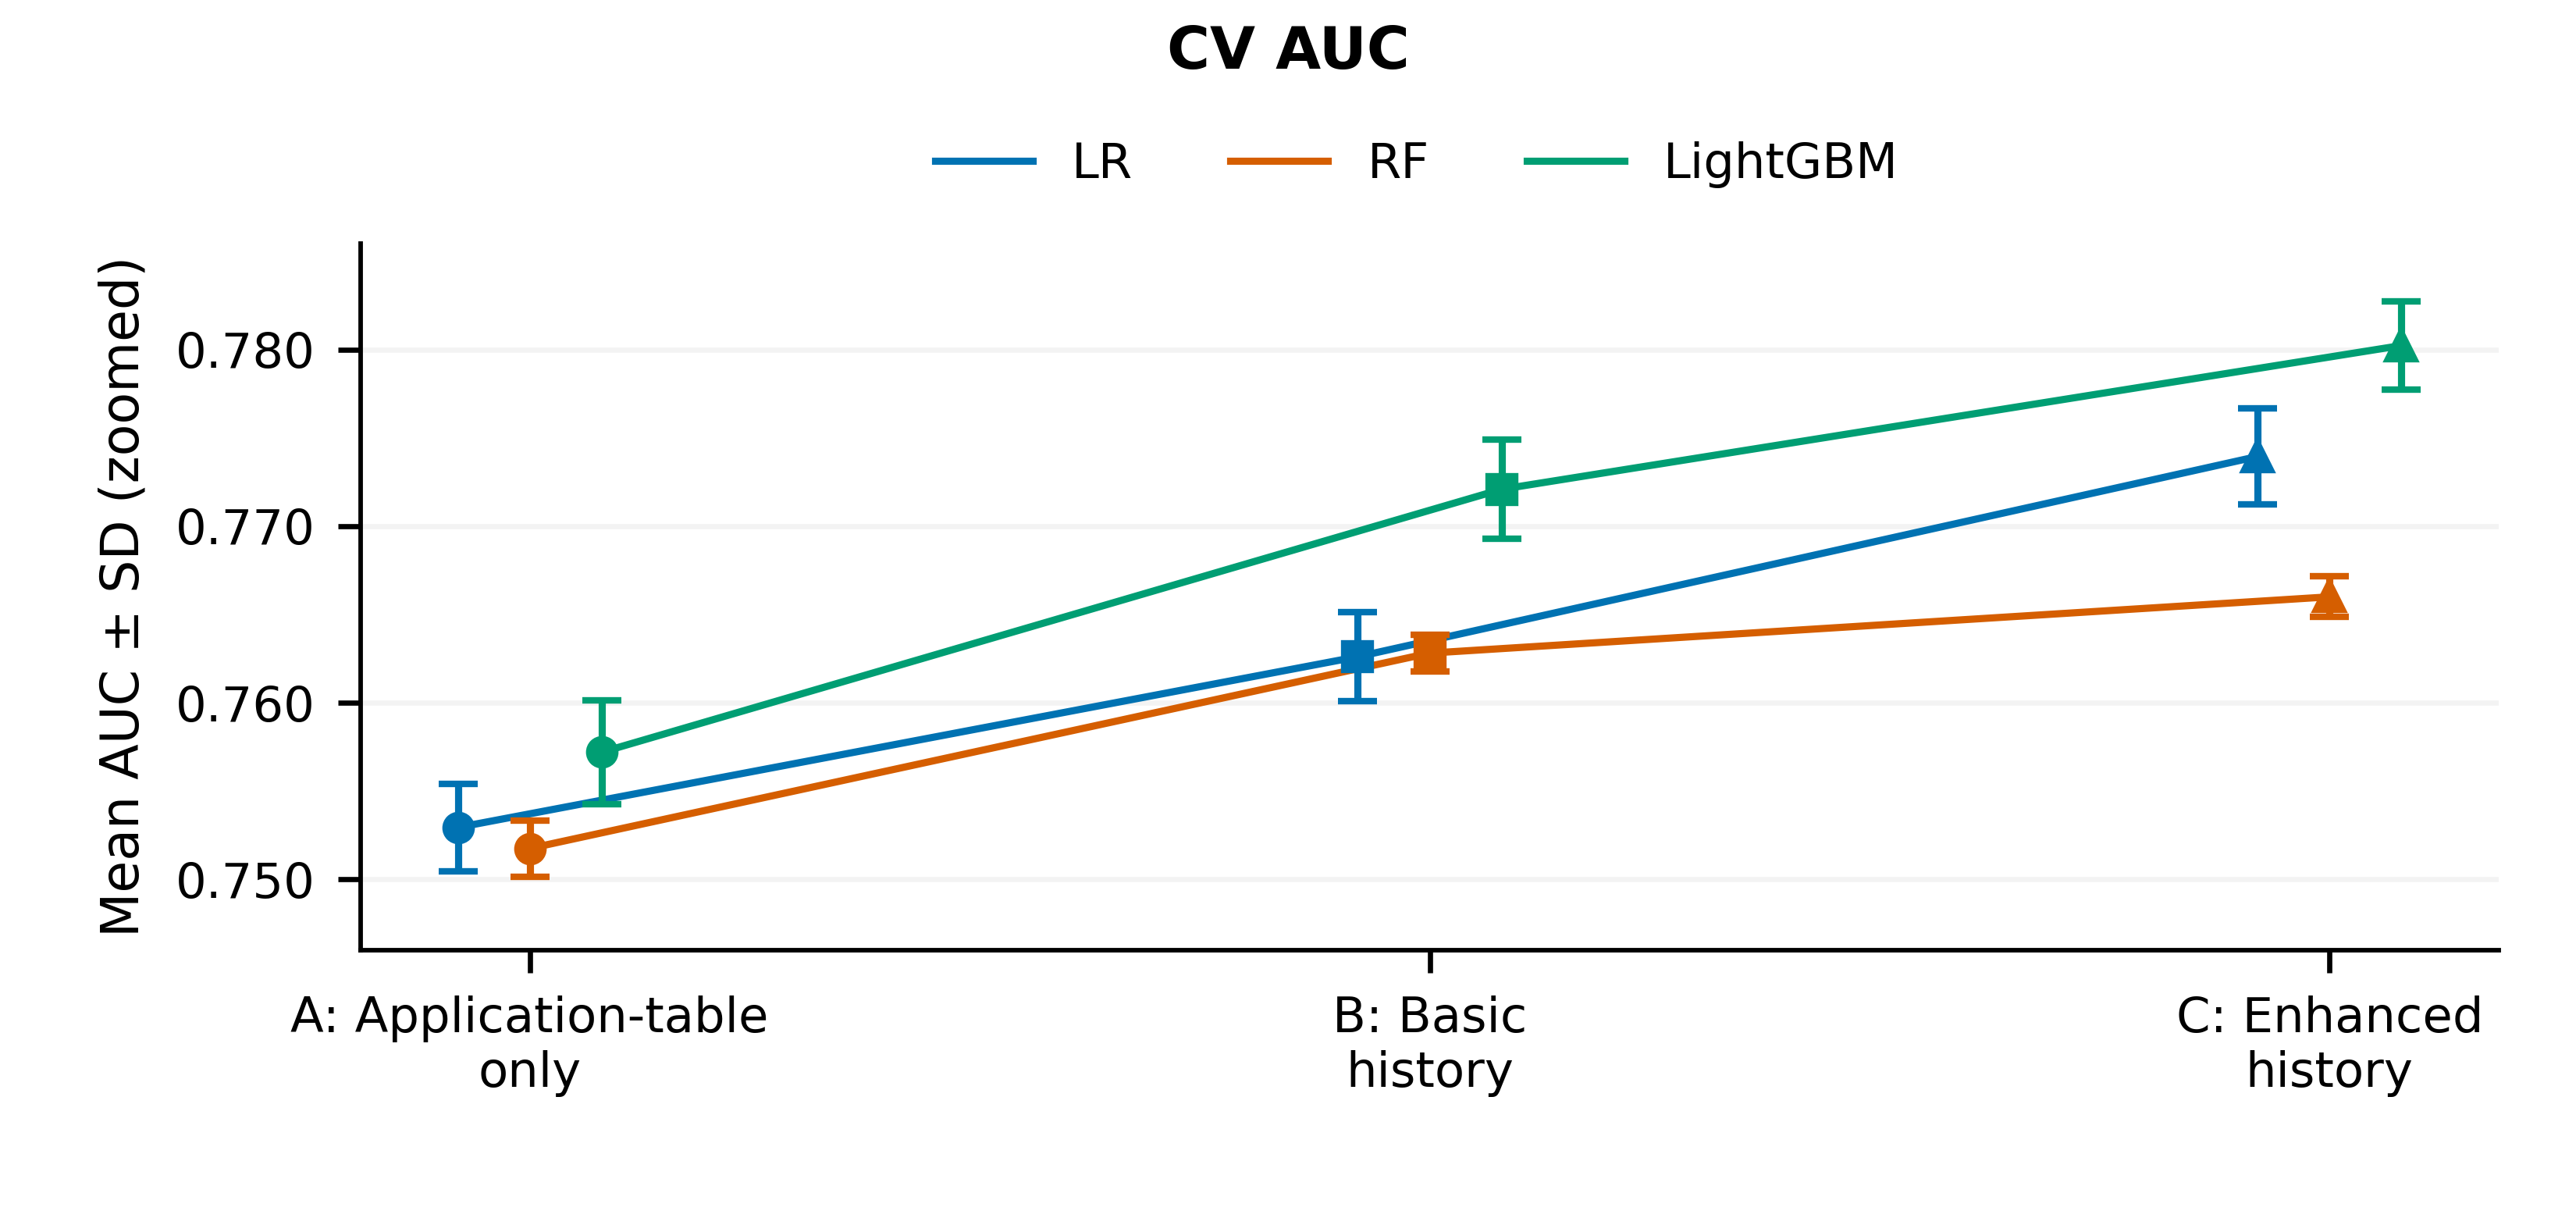

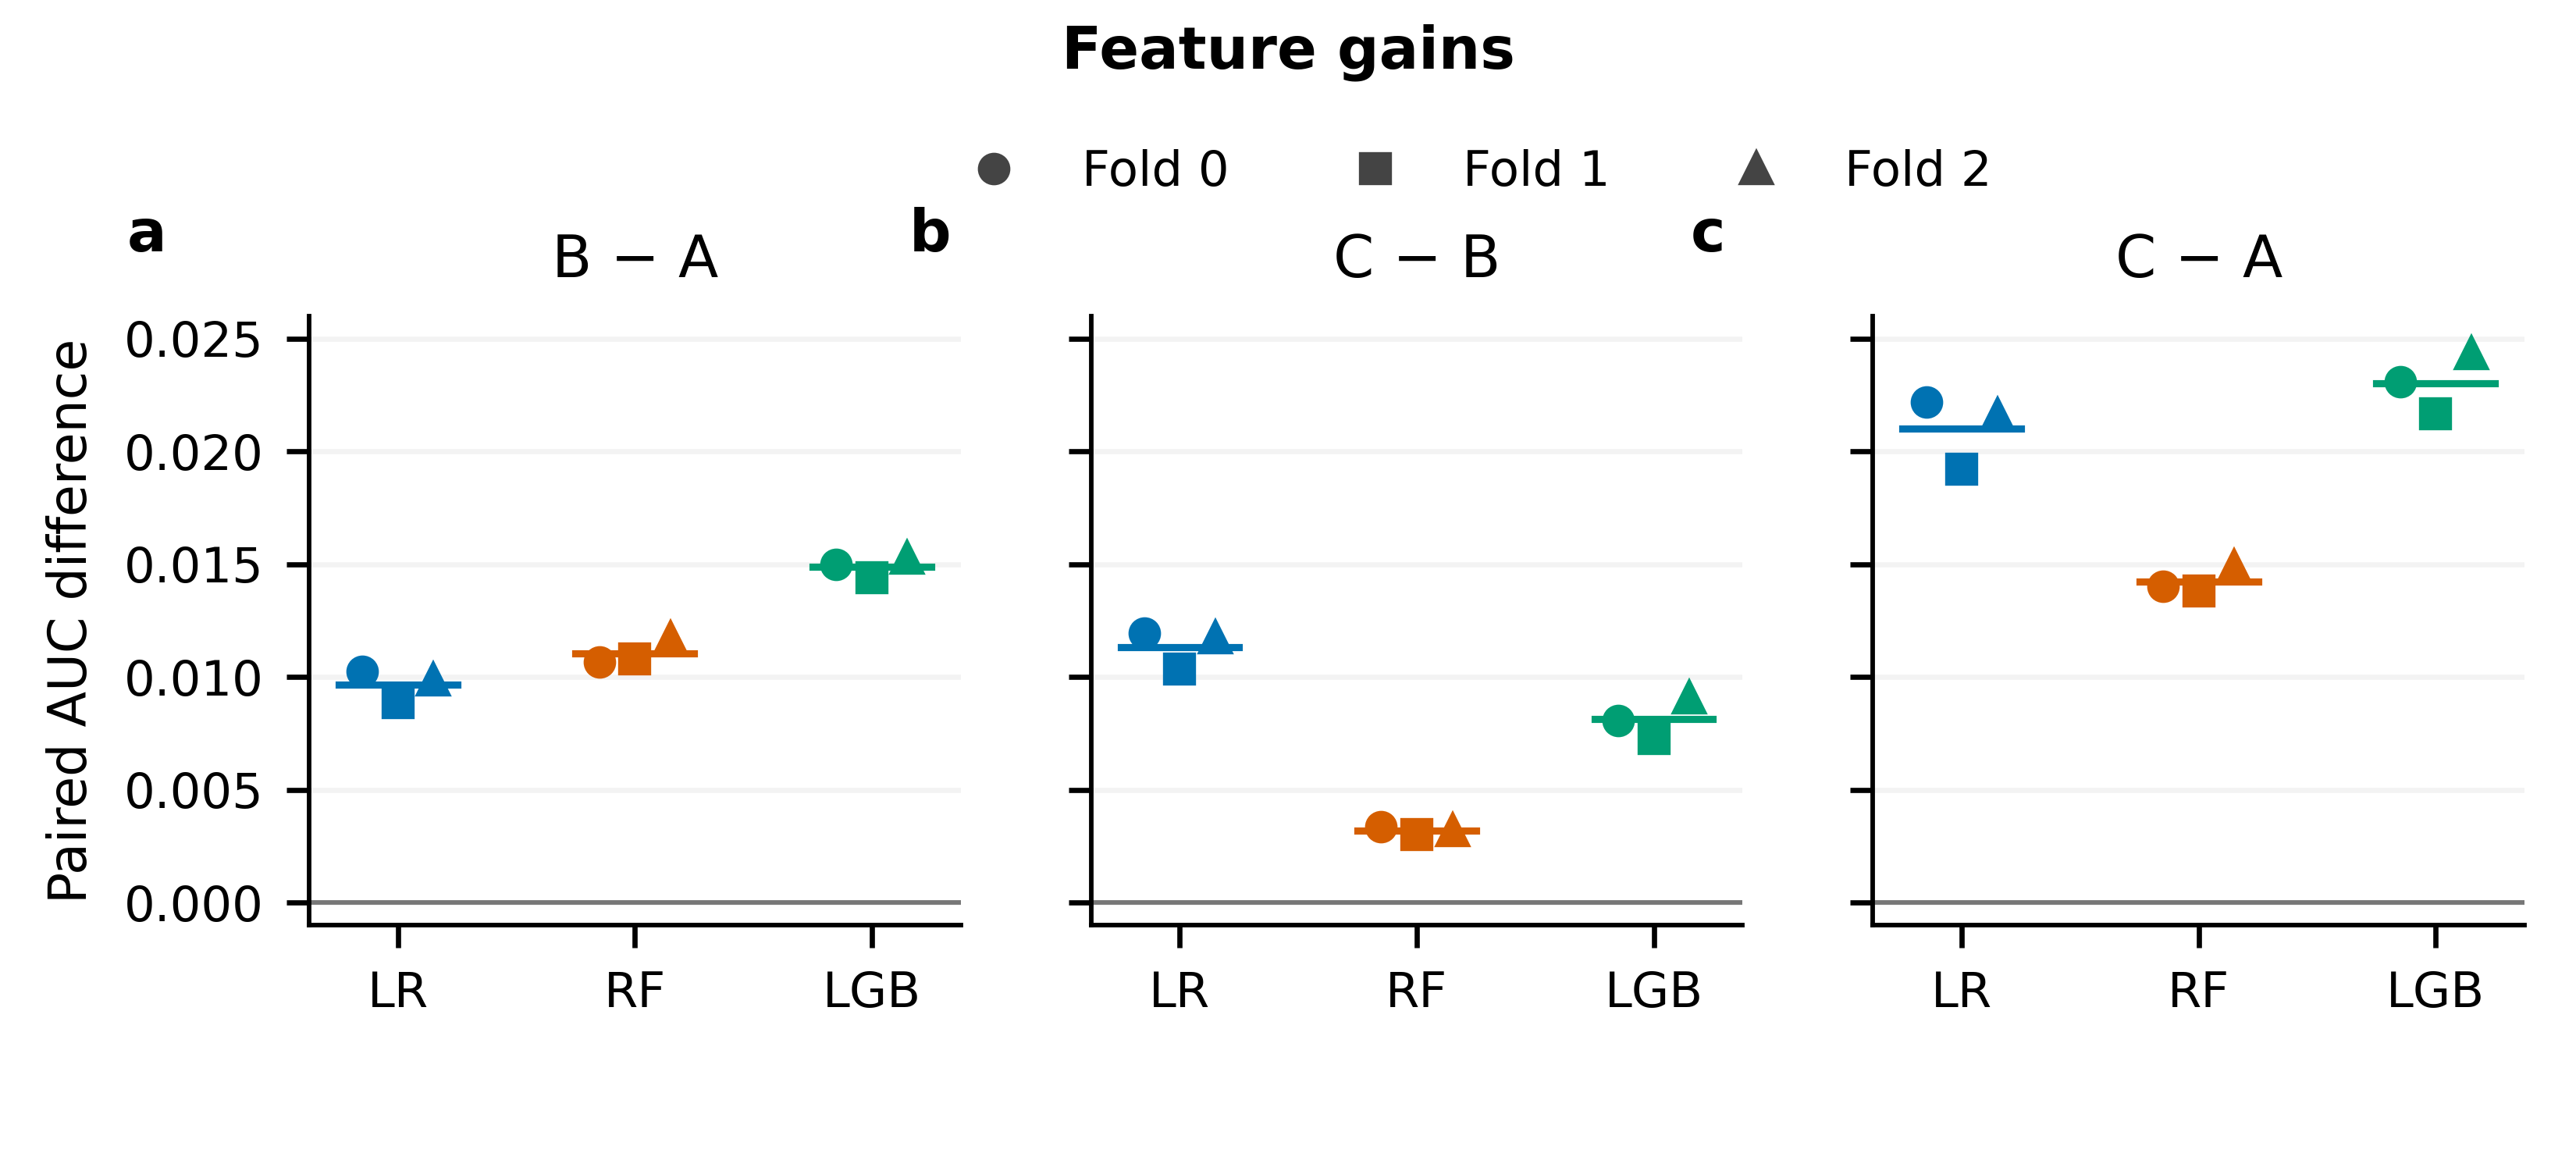

In [8]:
display(deltas.loc[deltas.fold.eq('mean')])
display(deltas.loc[~deltas.fold.eq('mean')])
for name in ['abc_auc','paired_deltas']:
    display(Image(filename=str(BASE.parent/'figures'/f'{name}.png'),width=900))

### Report Figure 2: compact information-stage evidence
This is the exact shared report export. Panel a uses uniform circles for A/B/C mean AUC with sample SD on a zoomed axis; b and c show B−A and C−B paired gains. The circle/square/triangle fold legend applies only to b/c. The preceding technical plot additionally includes C−A. Both use the same saved fold scores.

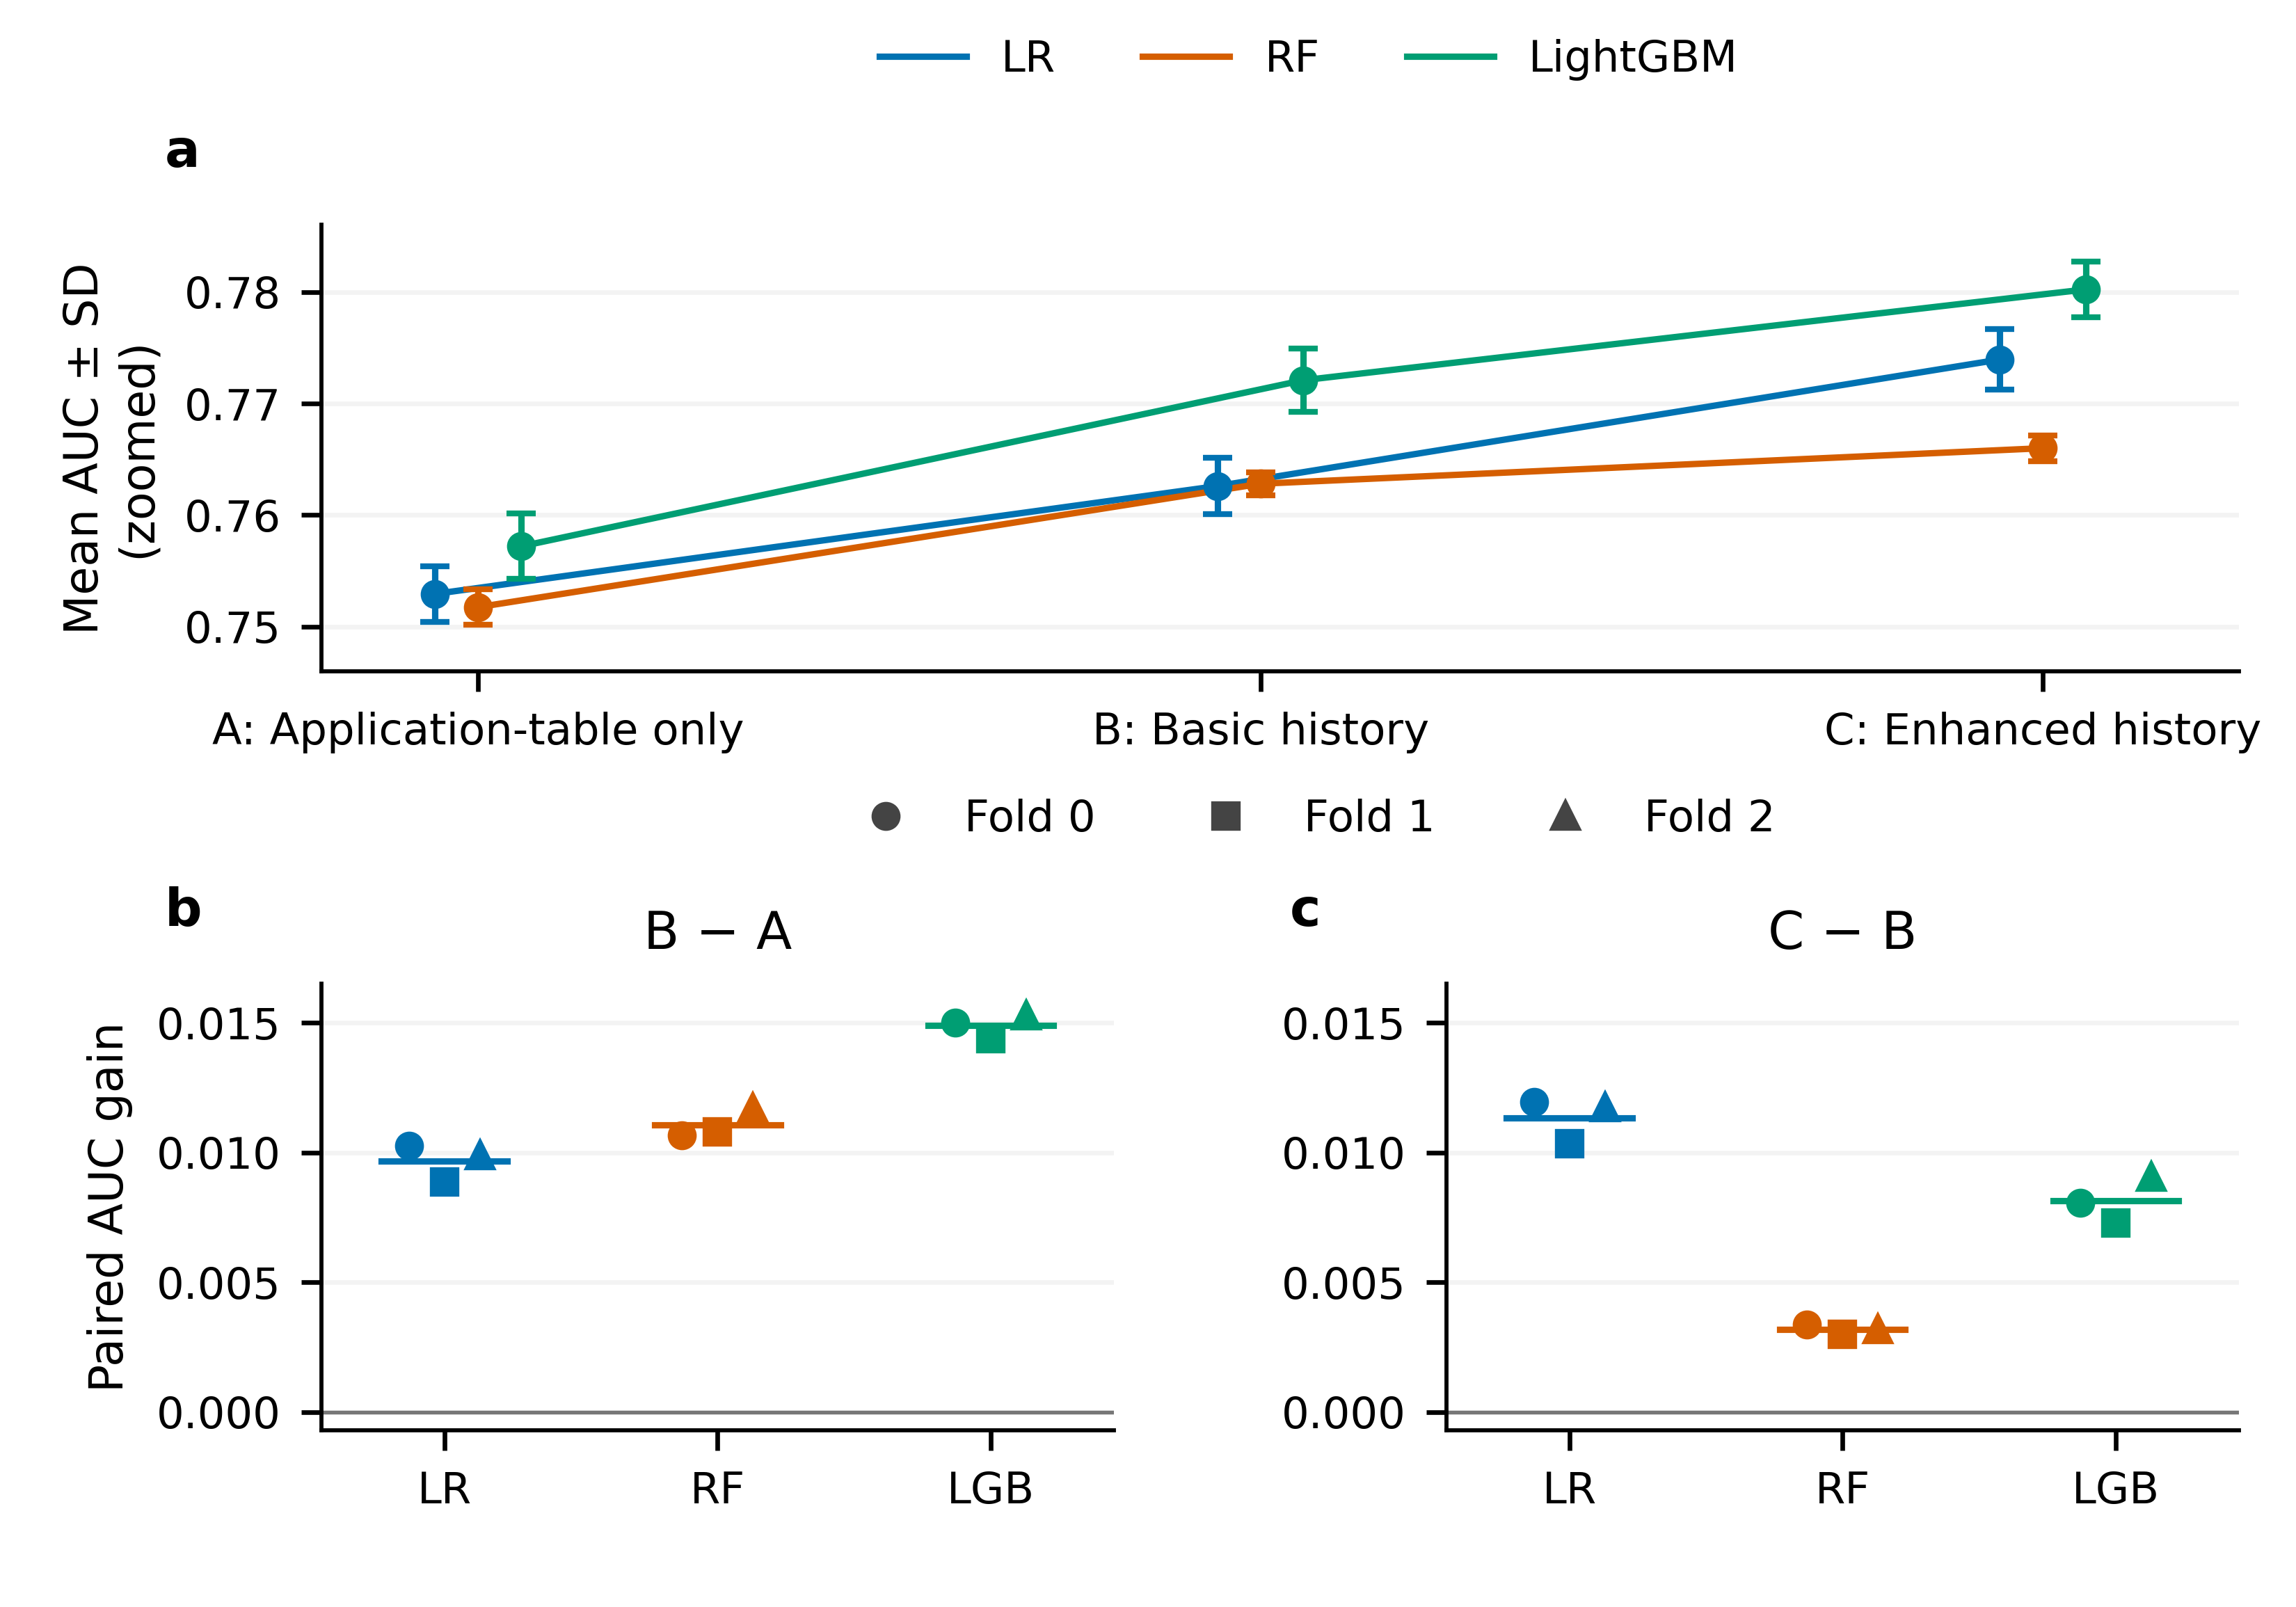

In [9]:
display(Image(filename=str(BASE.parent/'figures/history_gains.png'),width=800))

## 6. What do the results establish?
**RQ1. Historical information adds value under all three fixed pipelines.** Mean C−A AUC gains are 0.021006 for LR, 0.014248 for RF and 0.023029 for LGB. Both B−A and C−B have positive AUC/AP differences on every recorded fold. These are absolute AUC differences, not percentage increases in accuracy. This supports the incremental usefulness of the joined historical information and associated representations in this development experiment.

**RQ2. More complex does not automatically mean better.** LR is slightly above RF in A, slightly below it in B, and above it in C. LGB has the highest mean AUC in all three groups. The small LR/RF difference in B (about 0.000206) is a descriptive ordering, not an established significant difference. Because preprocessing, representations and fixed configurations differ, the comparison is between complete pipelines. It does not estimate a pure algorithm-complexity effect or establish an algorithm's attainable optimum.

The different gains may reflect complementary credit-state and repayment information or different model representations. This study has no per-mechanism intervention, so these are possible explanations. Coefficients and tree importances can describe model associations; they are not causal explanations, and importance values from different models have different scales.

## 7. Secondary analysis: already completed bounded optimisation
This block is separate from the fixed A/B/C comparison. It reuses the completed optimisation study and performs no search here. The original LGB-C mean AUC was 0.780230; C11-base achieved 0.781855; the rule-selected rank80/20 combination achieved 0.782349. The total development difference from original LGB-C was 0.002119.

**Keep negative outcomes.** Additional T and S features did not improve the fixed-configuration mean; TS improved the mean slightly but declined on one fold. None passed the prespecified stable-gain rule. Raw80/20 decreased AUC on all three folds. Improvements in the later scheme-selection stage must not be called gains from new features when the configuration changed and those features were not adopted.

**Why select two models rather than the highest score?** The frozen rule first requires mean gain >0.0003 and nonnegative gains on every fold relative to selected LGB. Among eligible schemes within 0.0003 of the maximum mean AUC, it prefers fewer component models. Rank70/20/10 scored 0.782638, but exceeded rank80/20 by only 0.000289, so the simpler two-model combination was selected. It is the rule-selected scheme, not the highest observed score.

The rank combinations use percentile ranks within each validation batch. Holdout/test use an OOF empirical-CDF transform, which is a different scoring rule. Batch-ranking development gains do not validate that deployment transform. All scores are uncalibrated. Sixteen optimisation development folds were flagged as possibly truncated; the final internal runs reached 2000/2000 rounds. This bounded study does not demonstrate full convergence or an algorithmic performance ceiling.

### Audit the completed bounded optimisation separately
**Inputs.** Saved candidate/feature tables, all 18 frozen candidate OOF files in one compressed table, and three fusion OOF files. **Outputs.** Stage summaries, negative feature trials, every fusion fold score, and a recomputed selection check. The fixed T/S/TS feature comparisons use C10_base as the reference, not C11. All 54 candidate fold AUC/AP pairs and 18 feature-contrast rows are recalculated below; this cell launches no search.

The parameter-only tolerance/simplicity rule selected C10 (AUC 0.781613), not C11. Including feature trials raised the maximum to C10_TS (0.781915), raising the eligibility floor to 0.781615 and excluding C10 by about 0.000002558. C11 then won in the combined pool, even though TS failed the nonnegative-fold gate and was not adopted. This dependence is preserved and verified, not silently repaired or described as independent sequential selection.

Twelve LightGBM configurations were budgeted: eight initial structural/weight variants and four refinements around the chosen anchor. Feature families T (four recent-minus-overall historical level differences), S (six delinquency summaries by current Active/Closed loan status) and their union TS were checked separately on the small frozen configuration range and were not adopted. C11 uses depth 2, learning rate .05, leaf minimum 100, L2=5, unweighted training and a 2,000-round/patience-100 cap. It uses the same nested stopping boundary as the original flow.

Fusion aligns saved OOF by ID and fold. Raw80/20 averages scores; rank80/20 and rank70/20/10 combine validation-batch percentile ranks. Mean AUC gain must exceed .0003 with no negative fold relative to C11. Among eligible candidates within .0003 of the best mean, fewer components win, then raw before rank. Holdout/test empirical-CDF scoring is a different transformation, explicitly distinguished below.

Configuration complexity is compared lexicographically by number of extra feature groups, depth, effective leaf cap, unweighted before balanced training, learning rate 0.1 before 0.05, larger minimum leaf size, then smaller L2. The combined-pool maximum is calculated before any extra-feature adoption check. If the selected candidate has extra features, its gain must exceed 0.0003 with no negative fold versus the parameter-only choice; otherwise selection falls back to that choice. Fusion instead filters eligible candidates before applying the tolerance and component-count rule. See `complexity`, `select_simple` and `run_search` in `source_snapshot/unified/optimization.py`.


In [10]:
candidate_folds, selection_audit = w.verify_secondary_candidates()
display(candidate_folds)
display(pd.Series(selection_audit))
opt_folds, opt_validation=w.verify_optimization()
display(w.read_csv('support/optimization/final_comparison.csv'))
display(w.read_csv('support/optimization/feature_paired_deltas.csv'))
display(pd.DataFrame(json.loads((BASE/'support/optimization/blend_summary.json').read_text()))[['tag','auc_mean','ap_mean','fold_deltas','stable_gain']])
display(pd.Series(opt_validation))

,tag,fold,roc_auc,ap
0,C00_base,0,0.783100,0.272543
1,C00_base,1,0.779081,0.274075
2,C00_base,2,0.778509,0.269964
3,C01_S,0,0.783745,0.274566
4,C01_S,1,0.779303,0.274884
5,C01_S,2,0.779432,0.271595
6,C01_T,0,0.784255,0.275616
7,C01_T,1,0.779743,0.276192
8,C01_T,2,0.778972,0.271353
9,C01_TS,0,0.784462,0.275551


status                                                                          PASS
candidate_folds                                                                   54
prediction_rows                                                              5258430
parameter_pool_choice                                                       C10_base
combined_pool_choice                                                        C11_base
combined_maximum                                                              C10_TS
combined_tolerance_floor                                                    0.781615
parameter_reference_below_floor                                             0.000003
feature_contrast_rows                                                             18
new_model_fits                                                                     0
scope                              Saved-score recalculation and frozen-rule repl...
dtype: object

,model,source,auc_mean,auc_sd,ap_mean,ap_sd
0,LR,"historical unified V2, verified reuse",0.773946,0.002712,0.259914,0.003725
1,RF,"historical unified V2, verified reuse",0.766000,0.001153,0.253352,0.004365
2,Original LGB,historical V2; fresh C00 exact reproduction,0.780230,0.002502,0.272194,0.002077
3,Optimized LGB,C11_base,0.781855,0.002306,0.275559,0.002955
4,Fusion,rank80_20,0.782349,0.002422,0.275676,0.002900


,kind,family,new_tag,reference_tag,fold,auc_delta,ap_delta
0,fixed_config,T,C10_T,C10_base,0,-0.000566,-0.000729
1,fixed_config,T,C10_T,C10_base,1,0.000479,0.000414
2,fixed_config,T,C10_T,C10_base,2,-0.000029,-0.000225
3,same_small_range_optimized,T,C10_T,C10_base,0,-0.000566,-0.000729
4,same_small_range_optimized,T,C10_T,C10_base,1,0.000479,0.000414
5,same_small_range_optimized,T,C10_T,C10_base,2,-0.000029,-0.000225
6,fixed_config,S,C10_S,C10_base,0,-0.000594,-0.000450
7,fixed_config,S,C10_S,C10_base,1,0.000930,0.001462
8,fixed_config,S,C10_S,C10_base,2,-0.000664,-0.001301
9,same_small_range_optimized,S,C10_S,C10_base,0,-0.000594,-0.000450


,tag,auc_mean,ap_mean,fold_deltas,stable_gain
0,raw80_20,0.781529,0.275691,"[-0.00024874725031232003, -0.00021059463593997...",False
1,rank80_20,0.782349,0.275676,"[0.0006220379225203576, 0.0004770786900540891,...",True
2,rank70_20_10,0.782638,0.276216,"[0.0007560821469180246, 0.0008217765238771602,...",True


status                                                           PASS
selection                                                   rank80_20
tolerance                                                      0.0003
higher_score_gap                                             0.000289
rank_scope          within-validation-fold percentile ranks; holdo...
new_model_fits                                                      0
dtype: object

### Report Figure 4: final base-configuration contrast and fusion
The top row compares final selected C11 with original C00 on enhanced history. It is not the parameter-only C10 choice. The lower rows compare fusion with C11. AUC and AP retain all folds and expose negative changes; no intervals are inferred from these three points.

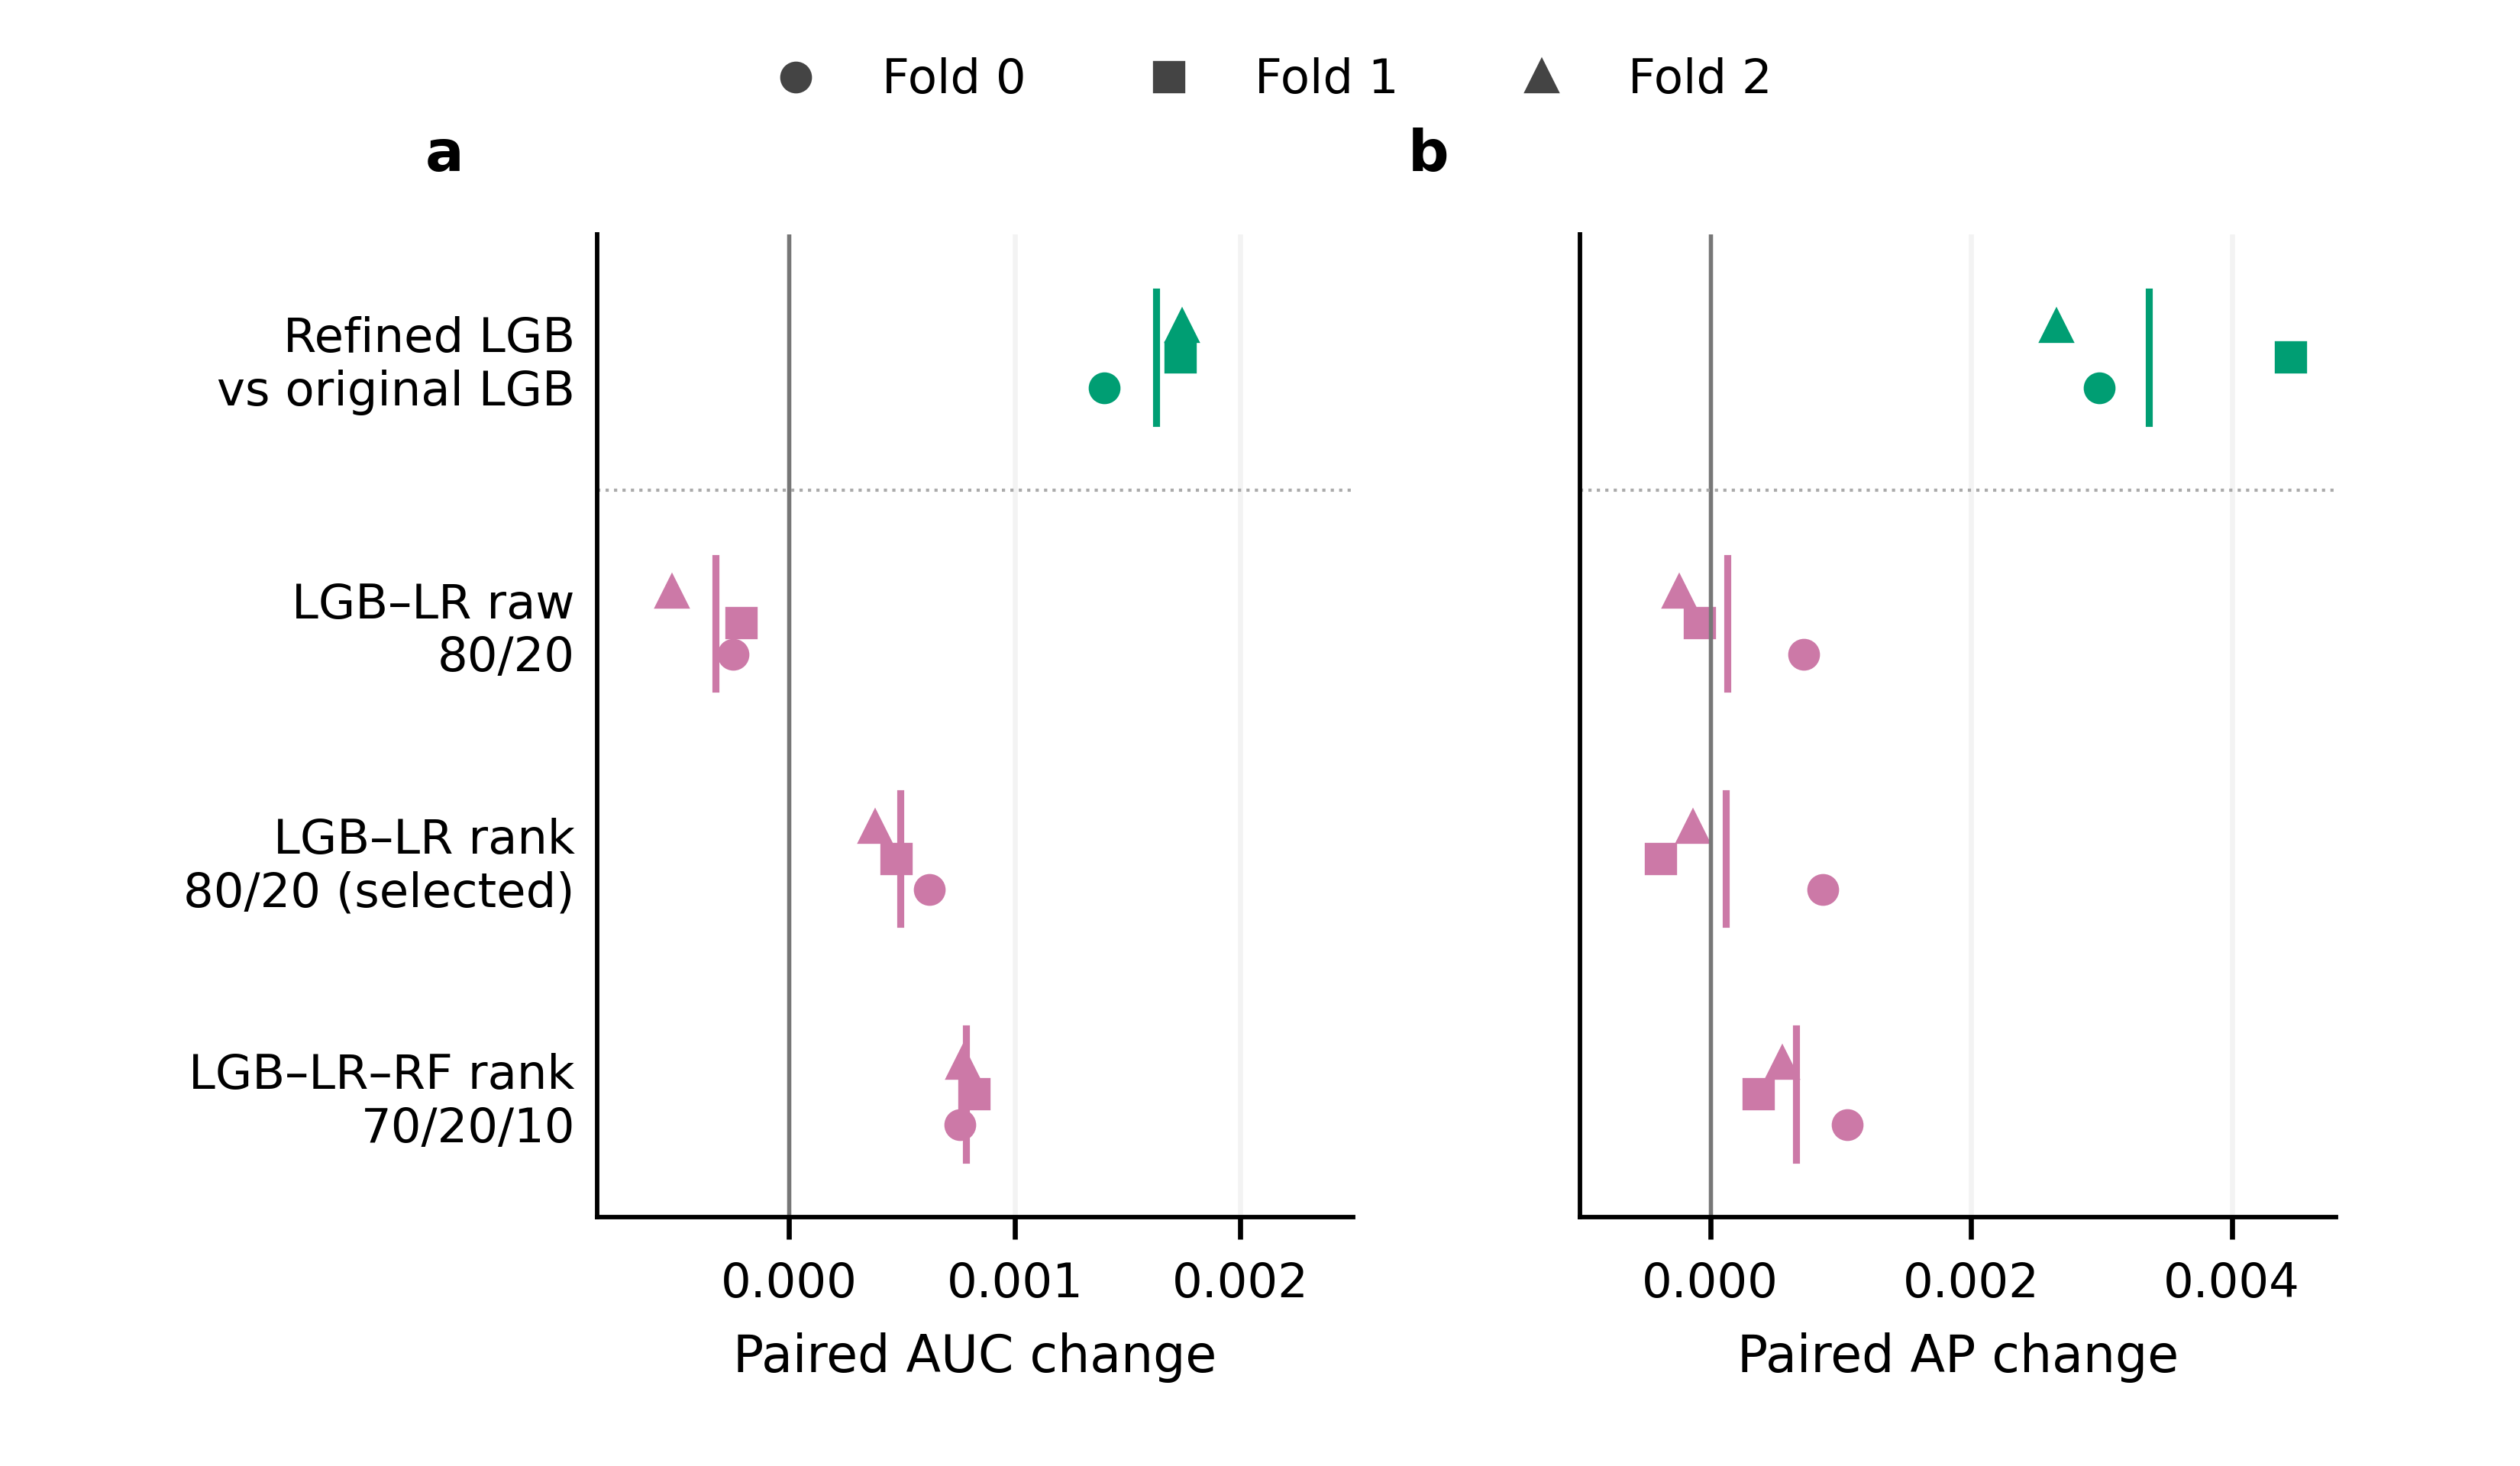

In [11]:
display(Image(filename=str(BASE.parent/'figures/refinement_effects.png'),width=800))

,id,params,weight,cap,patience,stage
0,C00,"{'objective': 'binary', 'metric': 'auc', 'lear...",balanced,1000,50,structure
1,C01,"{'objective': 'binary', 'metric': 'auc', 'lear...",unweighted,1000,50,structure
2,C02,"{'objective': 'binary', 'metric': 'auc', 'lear...",balanced,1000,50,structure
3,C03,"{'objective': 'binary', 'metric': 'auc', 'lear...",unweighted,1000,50,structure
4,C04,"{'objective': 'binary', 'metric': 'auc', 'lear...",balanced,1000,50,structure
5,C05,"{'objective': 'binary', 'metric': 'auc', 'lear...",unweighted,1000,50,structure
6,C06,"{'objective': 'binary', 'metric': 'auc', 'lear...",balanced,1000,50,structure
7,C07,"{'objective': 'binary', 'metric': 'auc', 'lear...",unweighted,1000,50,structure
8,C08,"{'objective': 'binary', 'metric': 'auc', 'lear...",unweighted,2000,100,refinement
9,C09,"{'objective': 'binary', 'metric': 'auc', 'lear...",unweighted,1000,50,refinement


,tag,config,family,fold,roc_auc,ap,seconds,fit_count,rounds,cap,iterations_run,possibly_truncated
0,C00_base,C00,base,0,0.783100,0.272543,22.772765,2,816,1000,866,False
1,C00_base,C00,base,1,0.779081,0.274075,21.870608,2,780,1000,830,False
2,C00_base,C00,base,2,0.778509,0.269964,26.625744,2,995,1000,1000,True
3,C01_base,C01,base,0,0.784205,0.274180,21.045869,2,750,1000,800,False
4,C01_base,C01,base,1,0.779819,0.275735,18.139378,2,636,1000,686,False
5,C01_base,C01,base,2,0.779749,0.271793,26.698641,2,1000,1000,1000,True
6,C02_base,C02,base,0,0.781944,0.272190,10.348366,2,234,1000,284,False
7,C02_base,C02,base,1,0.777684,0.272698,13.043778,2,320,1000,370,False
8,C02_base,C02,base,2,0.776055,0.268154,13.206809,2,325,1000,375,False
9,C03_base,C03,base,0,0.782088,0.272259,15.108042,2,391,1000,441,False


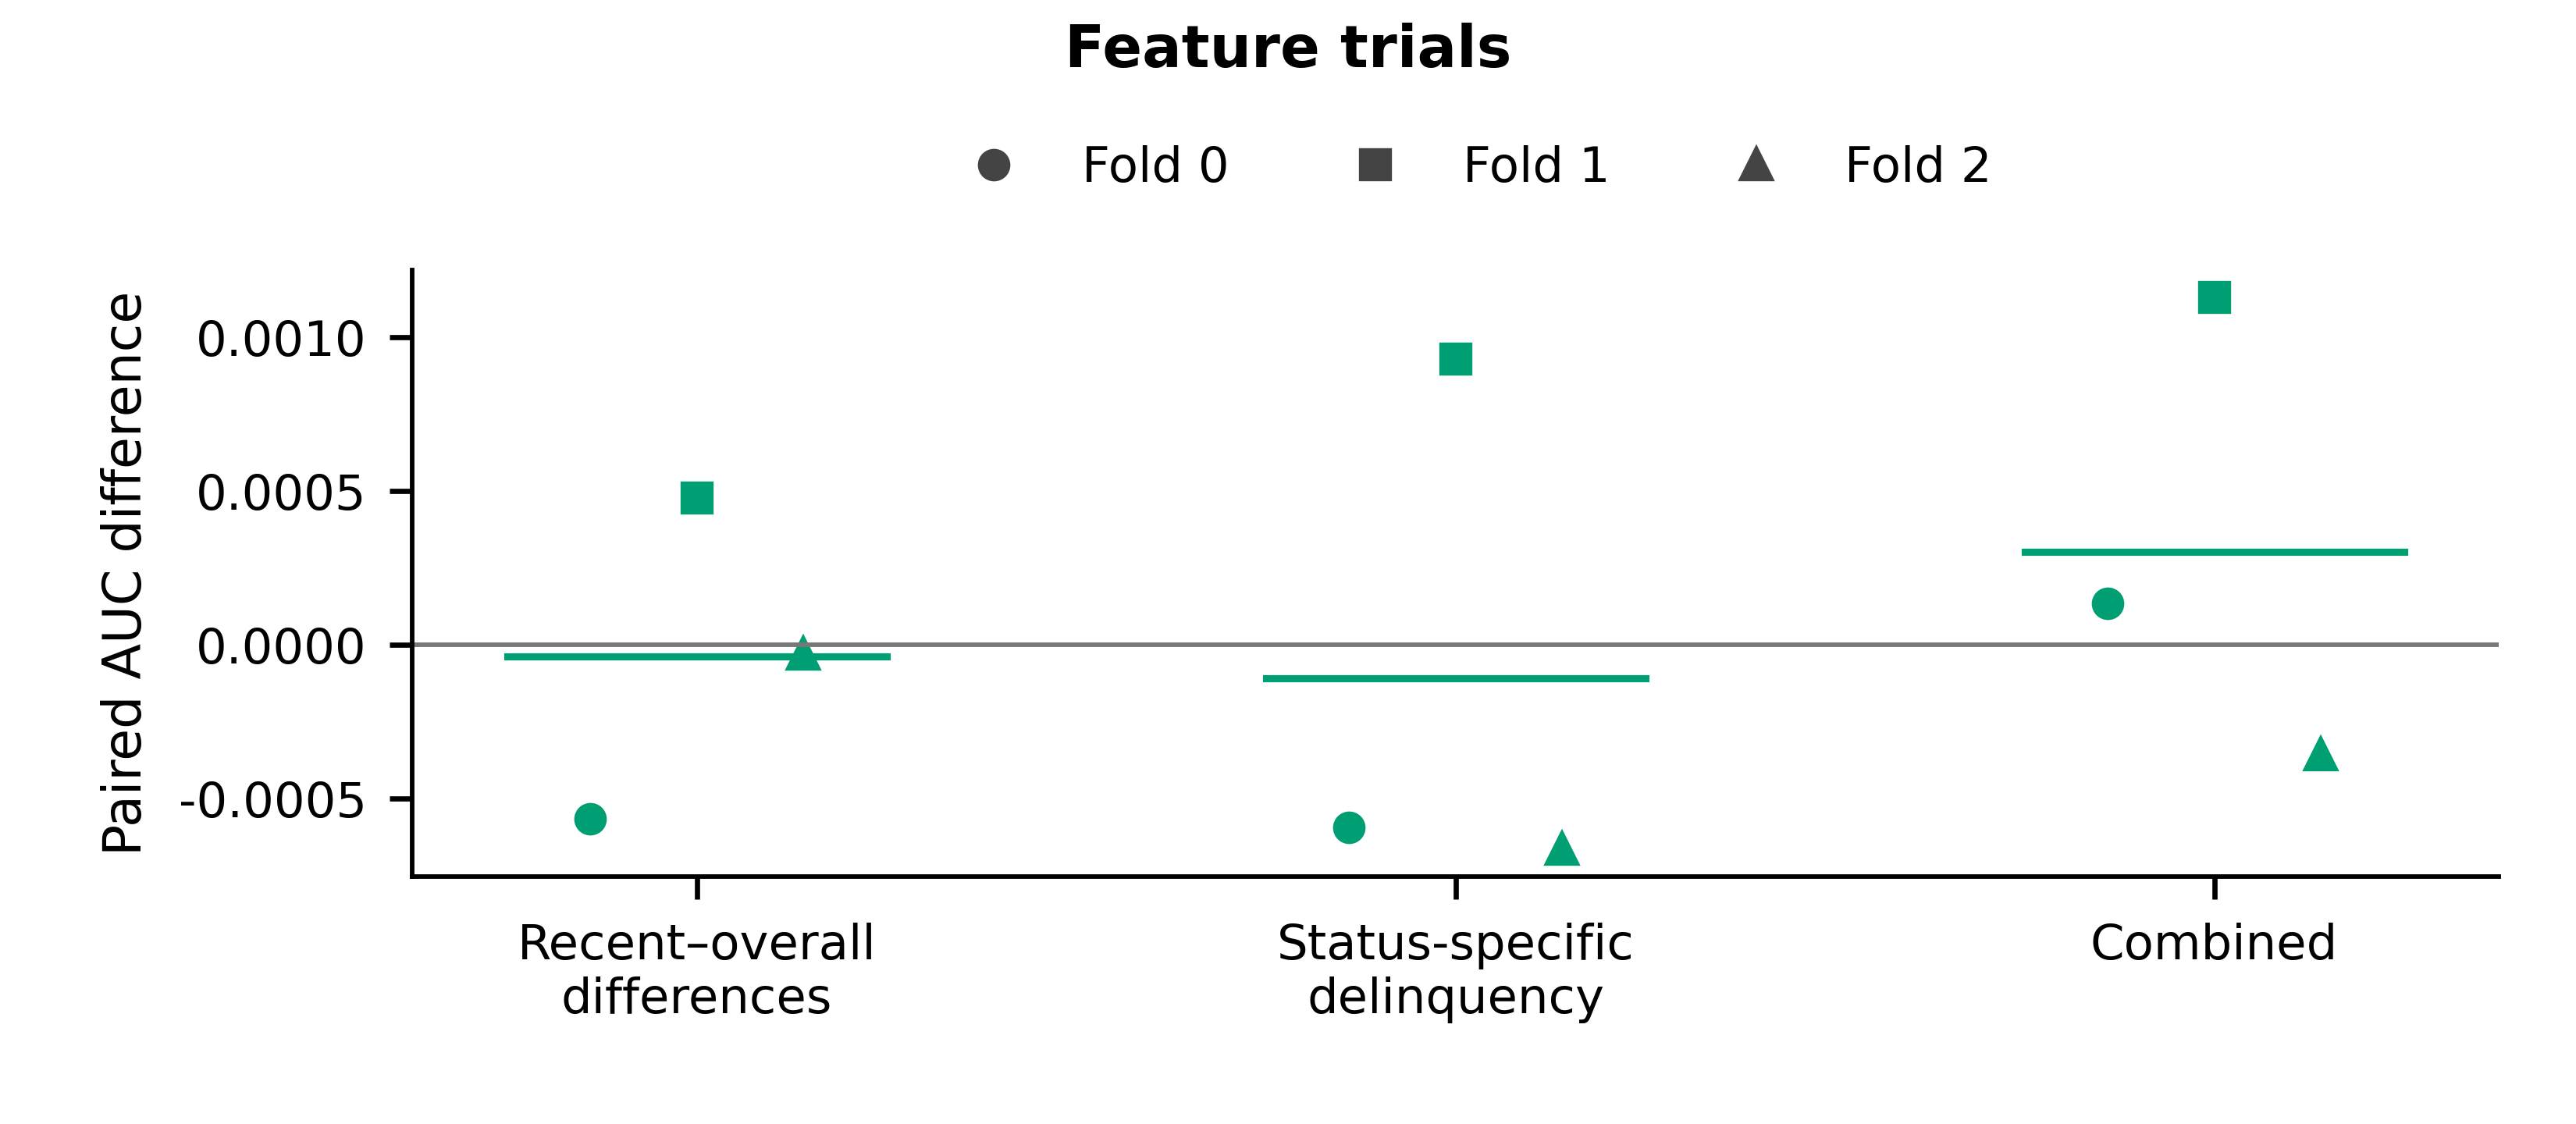

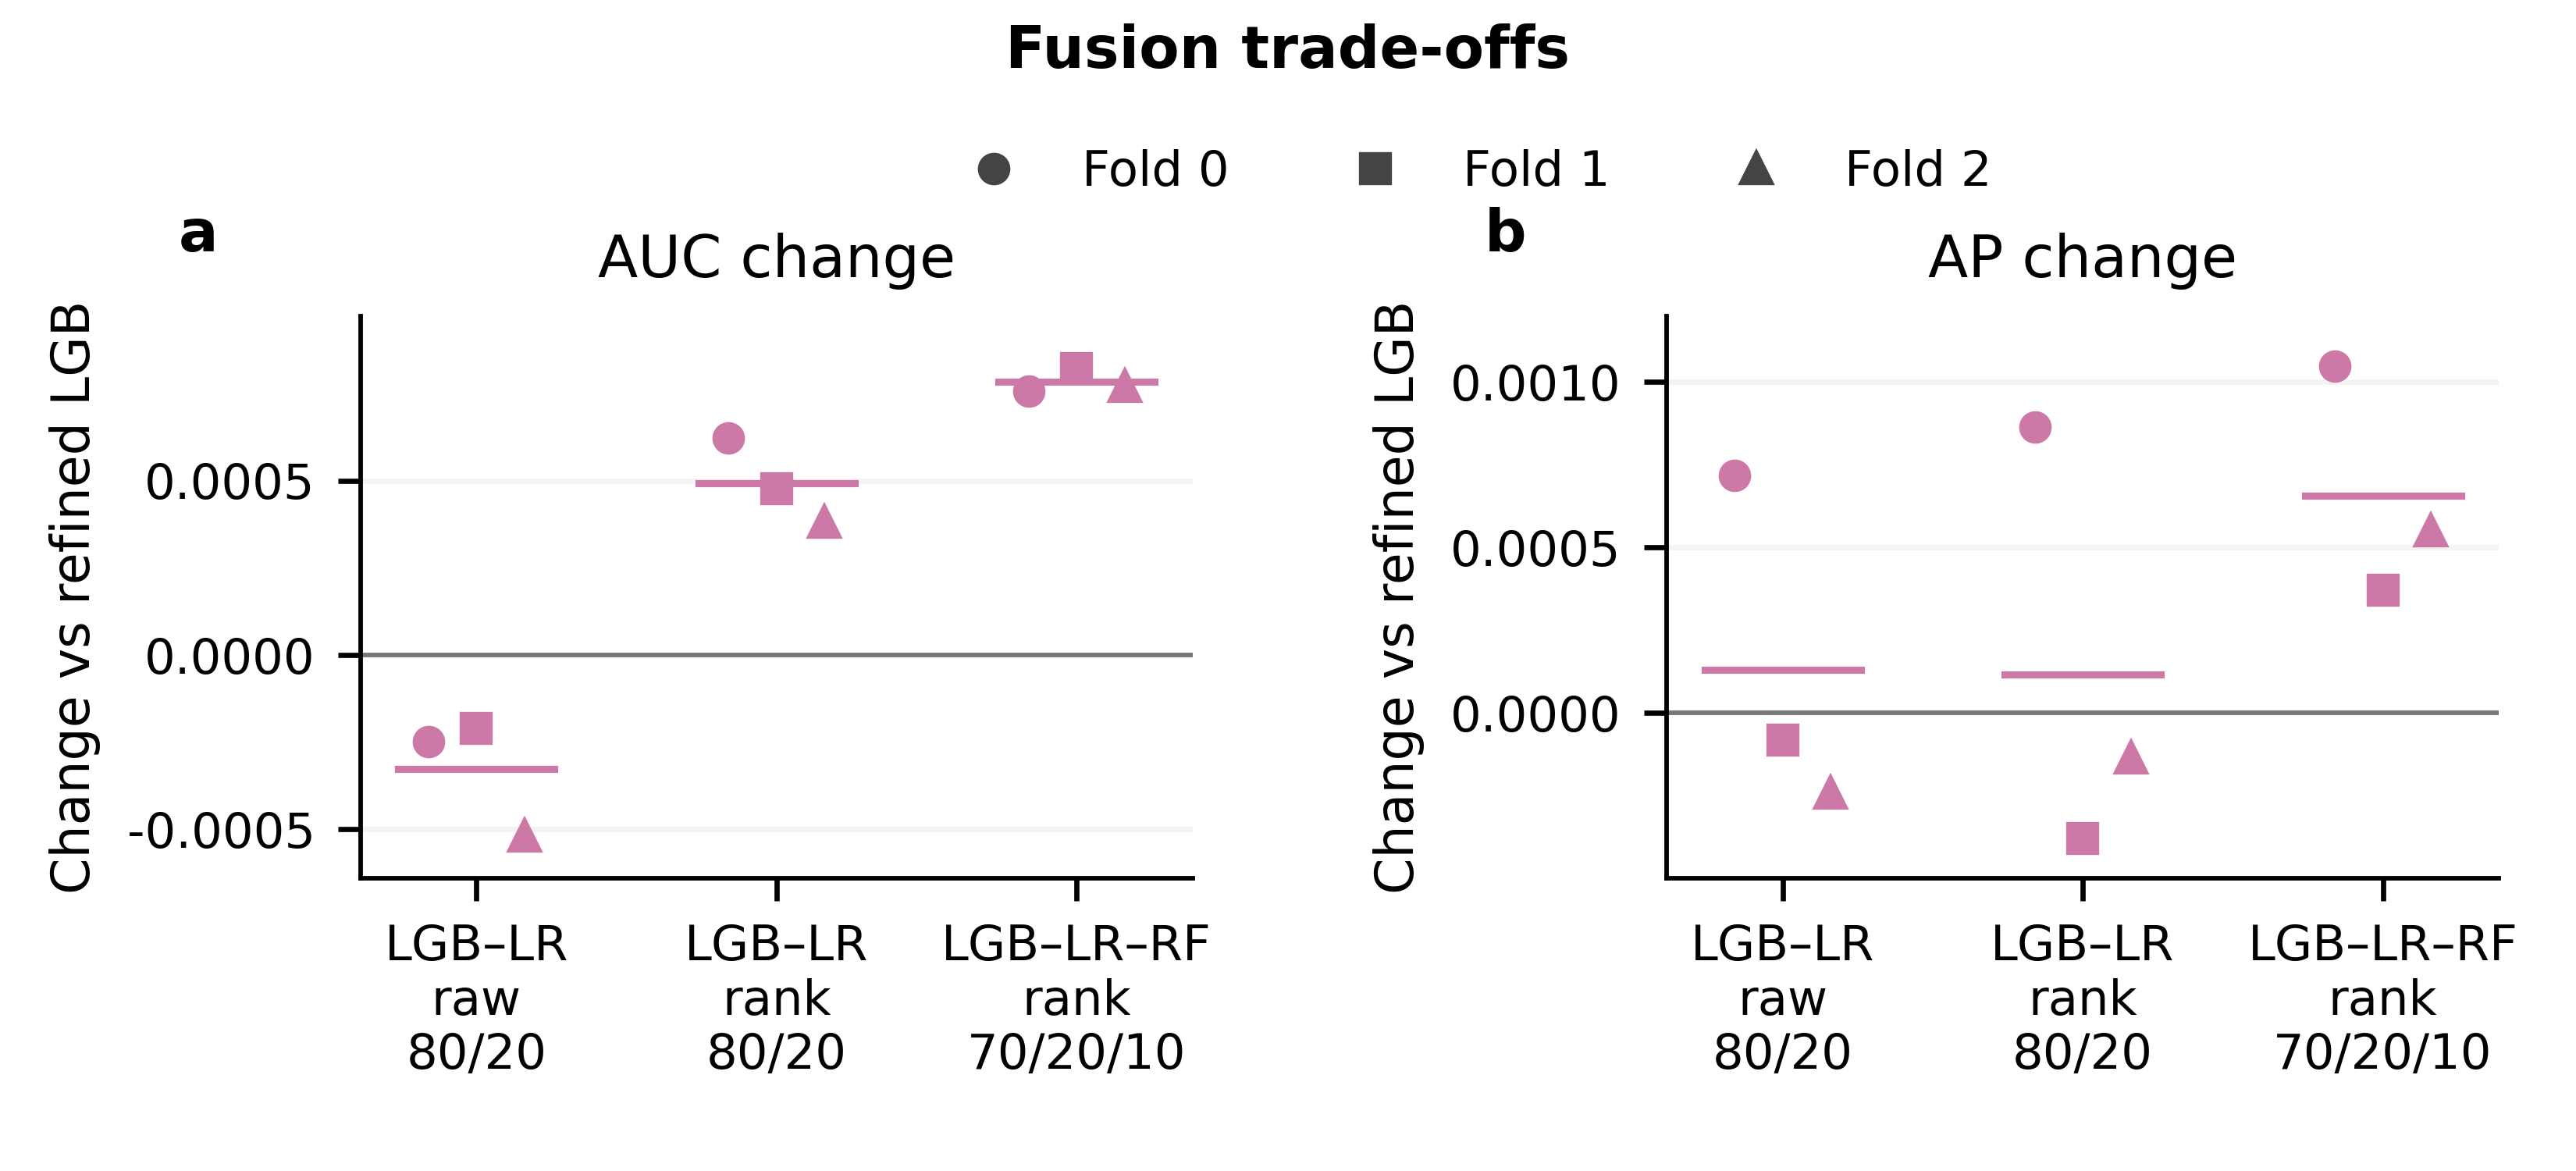

In [12]:
display(pd.DataFrame(json.loads((BASE/'support/optimization/materialized_configs.json').read_text())))
display(w.read_csv('support/optimization/cv_folds.csv'))
for name in ['feature_trials','fusion_deltas']:
    display(Image(filename=str(BASE.parent/'figures'/f'{name}.png'),width=800))

### Report Figure 3: original-C model diagnostics and supplementary holdout scores
The next diagnostics read existing coefficient/importance tables from original C full-development fits, not outer-fold averages, C11, or the fusion model. LR values are signed coefficients of transformed terms; RF values are impurity-based importance; LightGBM uses split gain. The figure selects five terms by absolute within-model value and keeps the complete tables beside it. Cross-model magnitudes and causal effects cannot be inferred from these scales. Absolute LR coefficients do not rank total original-variable effects. Transport type 3 is an organization-category dummy, document flags are dataset-numbered fields, and the RF debt ratio describes active debt. Original external-score fields rank highly in the tree models although additional history still adds fold AUC.

The holdout table is deduplicated across thresholds only because AUC/AP do not depend on the decision threshold. All five pipelines use enhanced-history C inputs on the same previously viewed 15,376 applicants. No SD is inferred from a single split. Fusion improves this split's AUC over C11 but reduces AP; this is supplementary descriptive evidence and does not justify further selection. The author-provided Kaggle screenshot reports Score 0.77948 and Private score 0.77738 for the submission labelled LGB–LR rank 80/20, marked Complete (after deadline). These platform scores are separate from CV and viewed-holdout metrics; no rank or new model selection is claimed. The accompanying evidence JSON records the local CDF submission identity and the limit of screenshot-based file matching.

,feature,value
0,CNT_CHILDREN,0.000000
1,AMT_INCOME_TOTAL,0.011133
2,AMT_CREDIT,0.252543
3,AMT_ANNUITY,0.096539
4,AMT_GOODS_PRICE,-0.788957
...,...,...
535,ANNUITY_INCOME_RATIO_sp_3,0.000000
536,ANNUITY_INCOME_RATIO_sp_4,0.000000
537,ANNUITY_INCOME_RATIO_sp_5,0.006531
538,INTERACT_EXT2_EXT3,-0.061348


,feature,value
0,numeric__CNT_CHILDREN,0.000825
1,numeric__AMT_INCOME_TOTAL,0.004816
2,numeric__AMT_CREDIT,0.008676
3,numeric__AMT_ANNUITY,0.010028
4,numeric__AMT_GOODS_PRICE,0.008109
...,...,...
356,categorical__WALLSMATERIAL_MODE_Unknown,0.000978
357,categorical__WALLSMATERIAL_MODE_Wooden,0.000008
358,categorical__EMERGENCYSTATE_MODE_No,0.001099
359,categorical__EMERGENCYSTATE_MODE_Unknown,0.001086


,feature,value
0,NAME_CONTRACT_TYPE,2055.670425
1,CODE_GENDER,12547.906134
2,FLAG_OWN_CAR,43.665100
3,FLAG_OWN_REALTY,0.000000
4,CNT_CHILDREN,0.000000
...,...,...
184,BB_MAX_SEVERITY,0.000000
185,BB_LATEST_OVERDUE_LOAN_RATE,0.000000
186,BB_LATEST_CLOSED_LOAN_RATE,385.177299
187,BB_RECENT6_OVERDUE_LOAN_RATE_MEAN,372.890999


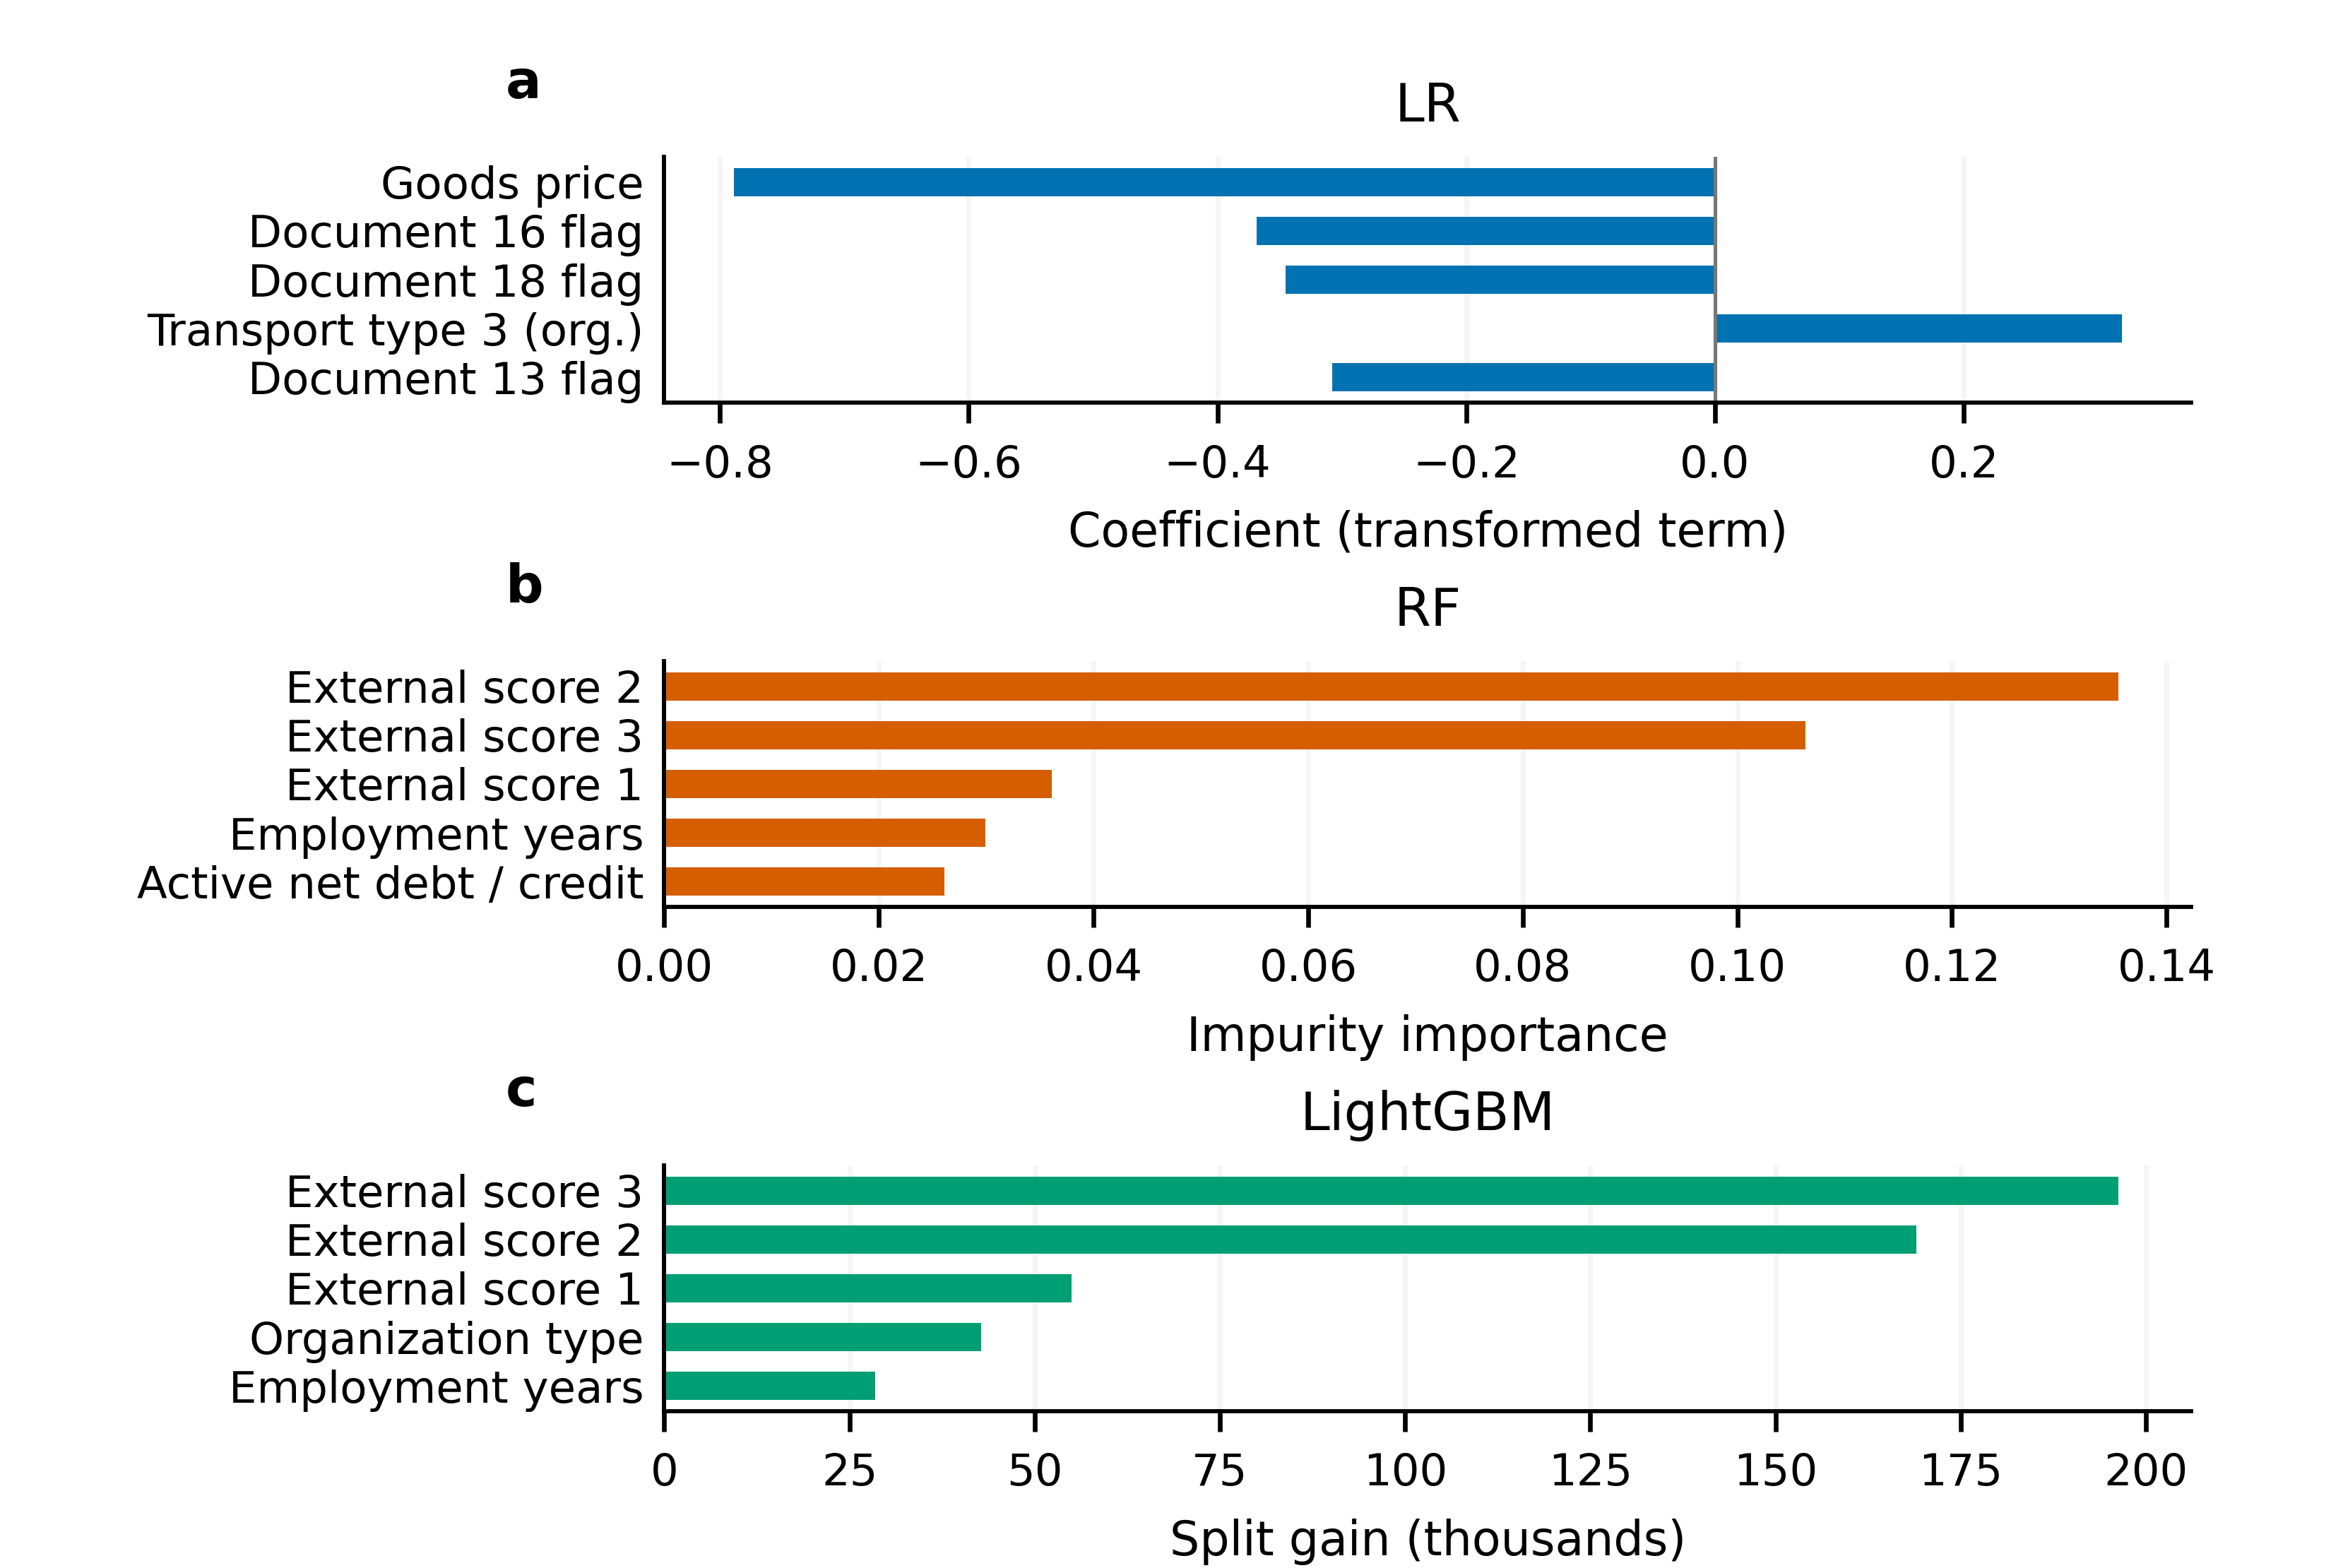

,model,roc_auc,ap
0,LR,0.773467,0.249358
1,RF,0.769716,0.250608
2,LGB,0.778127,0.266457
3,LGB_optimized,0.779527,0.269148
4,Fusion,0.780285,0.266881


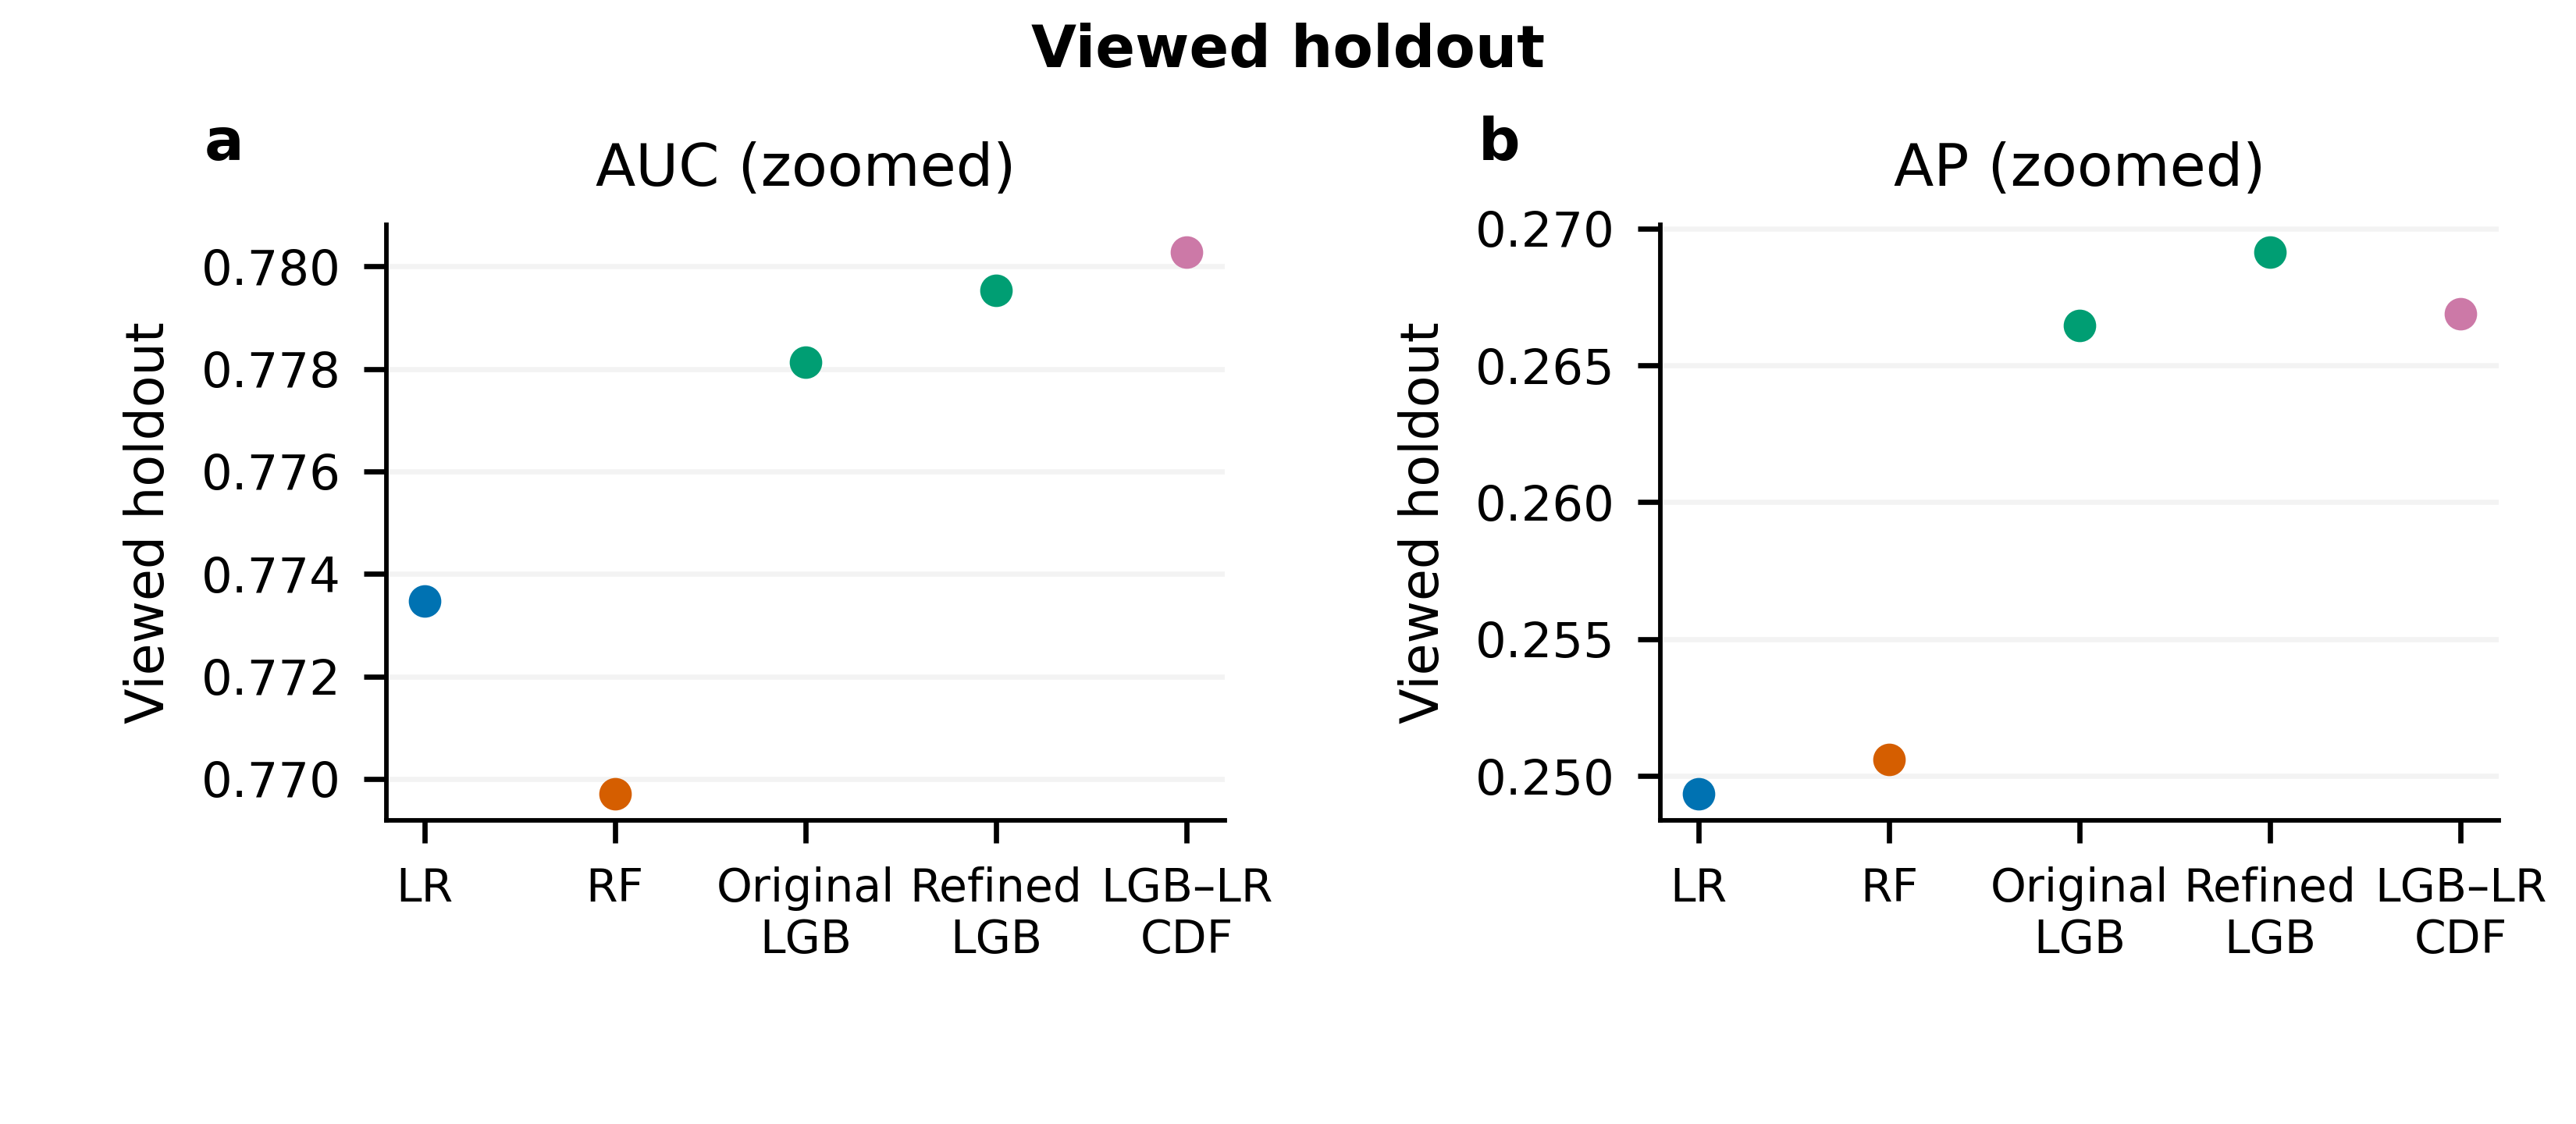

,submission_description,displayed_score,private_score,status_displayed,official_leaderboard_rank
0,LGB–LR rank 80/20,0.77948,0.77738,Complete (after deadline),None


In [13]:
for model in ['LR','RF','LGB']:
    display(w.read_csv(f'support/interpretation/{model}_importance.csv'))
display(Image(filename=str(BASE.parent/'figures/model_diagnostics.png'),width=800))
display(w.read_csv('support/report_data/holdout_plotted.csv')[['model','roc_auc','ap']])
display(Image(filename=str(BASE.parent/'figures/holdout.png'),width=800))
kaggle_evidence=json.loads((BASE/'support/kaggle/kaggle_submission_20261007.json').read_text())
display(pd.DataFrame([{k:kaggle_evidence[k] for k in ['submission_description','displayed_score','private_score','status_displayed','official_leaderboard_rank']}]))

## 8. Evaluation boundaries
These metrics describe a retrospective, fixed-protocol development comparison. Three folds share training data; their SD is not a confidence interval. The development data have been explored, and the 5% holdout was previously viewed. This notebook does not present a fresh external test, a significance test, calibrated risk probabilities, fairness/financial-inclusion evidence or lending-policy utility. It does not claim that complex models always win, that all historical mechanisms were isolated or that further features always improve prediction.

The author-provided Kaggle screenshot records Score 0.77948 and Private score 0.77738, with status Complete (after deadline). It supports these displayed platform results, not an official leaderboard rank or a byte-level match to a downloaded uploaded file. No upload or new model selection is performed here.



## 9. Reproduction levels and optional training
Default Run All is portable and uses only the accompanying `support/`, `source_snapshot/`, helper files and `../figures/`. It verifies saved evidence and its arithmetic; it is not a claim of fresh model training or a raw-data reconstruction.

For a deliberate fresh fixed-CV reproduction, install `requirements.txt`, provide the exact processed V1/V2 tables, raw `application_train.csv` and original membership under the documented project layout, then enable the next cell. Input and source hashes are checked. A alone requires 12 model fits; all three groups require 36, including LGB internal fits. Output must be a new directory. This GitHub organization checks the training CLI but does not retrain models. Prior partial training checks are summarised in README; internal validation logs are omitted. The original feature construction code is included. Original data must be downloaded separately; `reproduce.py data` rebuilds the processed tables from it.

No code in the default path fits a final official-submission model or uses holdout labels for selection.

### Deliberate reruns are separate from this inspection run
The next cell defaults to `RUN_FIXED_CV=False` and adds zero fits. A deliberate opt-in requires verified raw/processed data and a new output directory. It calls the unchanged training implementations and refits all learned processing inside the appropriate training subset. Existing output directories are rejected to protect locked evidence. No cache mismatch is repaired by training automatically.

A costs 9 outer fits plus 3 LightGBM inner fits; all A/B/C groups cost 36 fits. These counts describe the optional command, not work performed by this notebook verification. See [the reproduction instructions](README.md#retrain-from-original-data) for raw reconstruction, frozen A/B/C training and the fixed secondary candidate set. README distinguishes prior raw reconstruction, saved-model replay and limited real training checks from the unexecuted full retraining suite. This repository includes no internal review logs.

In [14]:
RUN_FIXED_CV = False
DATA_ROOT = None  # Set to the project root containing processed_data/, baseline/splits/, home-credit-default-risk/.
GROUPS_TO_TRAIN = ['A']  # Set ['A','B','C'] only for a deliberate 36-fit reproduction.
if RUN_FIXED_CV:
    assert DATA_ROOT is not None, 'Set DATA_ROOT explicitly before opting in.'
    from datetime import datetime, timezone
    from train_fixed import train
    destination=BASE/'reruns'/datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S%fZ')
    train(DATA_ROOT,destination,GROUPS_TO_TRAIN)
else:
    print('No model fitting requested. This notebook run added 0 fits.')

No model fitting requested. This notebook run added 0 fits.


## Source and evidence guide
- The course report and source/reproduction entrypoints are linked from the [repository README](../README.md).
- Dataset: [Home Credit Default Risk](https://www.kaggle.com/competitions/home-credit-default-risk). This is a source pointer; no live leaderboard evidence is claimed.
- Primary numbers: `support/abc/cv_folds.csv`, `cv_summary.csv`, `paired_deltas.csv`, and the losslessly compressed OOF CSV.
- Field provenance: `support/abc/feature_sets.json`; original shared training definitions: `source_snapshot/`.
- Secondary development analysis: `support/optimization/`, kept separate from the fixed ablation.
- The accompanying [Report.pdf](../report/Report.pdf) contains the scientific narrative, overall conclusion and formal declarations. The notebook retains local interpretation and technical limits.